<a href="https://colab.research.google.com/github/Fyatto-He/thai_crop_class/blob/main/HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1: Evaluating Language Technologies
This assignment must be completed in order to be considered for enrollment in the class. If you are already enrolled, failure to complete this assignment will result in your removal from the course.

## Introduction
In this assignment, we will explore different tasks core to the field of NLP. You will implement different evaluation metrics for these tasks and perform analysis of different language
technologies.

Learning objectives:
* Understand the breadth of tasks core to the field of NLP.
* Implement various evaluation methods for core NLP tasks.
* Become familiar with prompting existing LLMs via API calls.
* Identify the limitations of automatic evaluation methods.
* Practice using error analysis to identify where language technologies fail and hypothesizing why they might fail.
* Appreciate things we humans do with language that current language models cannot do.

**Notes:**
* In your solution, keep all code as-is except where it's explicitly mentioned to implement a function.
* Items marked with a star (★) should be answered in markdown text in the notebook. You will include your final notebook as a pdf with your submission.
* Results are written to the `results/` sub-directory as you go, and these are what get autograded.

**Submission:**

When you are done, run `python3 make_submission.py`. It checks that every file the
notebook should have written is present, valid, and actually filled in, then packs
them into `submission.zip` for you to upload to gradescope. Two things go in it:

* All the json files saved inside the `results/` directory. These will be autograded.
* A PDF copy of your completed notebook, titled "HW1.pdf". This is used to grade your answers to the problems marked with a (★), so check that your plots rendered before exporting.

**Setup:**
You will need to download ollama https://ollama.com and install the following models with the commands:

`ollama pull qwen3:8b`

`ollama pull llama3.2:1b`

`ollama pull llama3.2`

`ollama pull gemma3:1b`

`ollama pull gemma3:4b`

You will need about 13GB of storage to download these models. Make sure the ollama binary is in /usr/local/bin/ or you know where it is, so you can call it on the command line.

## Running on Google Colab

Set **Runtime → Change runtime type → GPU**, then run the cell below once. It
clones the repo, installs everything, points your inference cache at Drive so a
disconnect can't throw away work, and starts ollama.

Running on your own machine instead? The cell does nothing — follow the README.

In [1]:
# Colab setup. On a local machine this cell is a no-op.
import sys

if "google.colab" in sys.modules:
    import os, subprocess, time

    STUDENT_REPO = "https://github.com/zinengtang/cs183-fall26-a1.git"
    DRIVE_DIR = "/content/drive/MyDrive/cs183-a1"

    # 1. code and data, since opening a notebook from GitHub brings only the notebook
    if not os.path.exists("/content/repo"):
        subprocess.run(["git", "clone", "-q", STUDENT_REPO, "/content/repo"], check=True)
    os.chdir("/content/repo")

    # 2. dependencies (ffmpeg is already on Colab). Capture rather than -q: a bare
    #    CalledProcessError tells you nothing about which package refused to install.
    installed = subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"],
                               capture_output=True, text=True)
    if installed.returncode != 0:
        print(installed.stdout[-2000:])
        print(installed.stderr[-2000:])
        raise RuntimeError("pip install failed -- see the output above for which package and why")

    subprocess.run([
      sys.executable, "-m", "pip", "install",
      "--force-reinstall", "--no-cache-dir",
      "numpy==2.2.6",
      "scipy==1.16.2"
    ], check=True)

    # 3. keep generations and results on Drive -- the runtime's own disk does not
    #    survive a disconnect, and re-running inference costs far more than this does
    from google.colab import drive
    drive.mount("/content/drive")
    for sub in ("inference_cache", "results"):
        os.makedirs(f"{DRIVE_DIR}/{sub}", exist_ok=True)
        subprocess.run(["rm", "-rf", sub], check=True)
        os.symlink(f"{DRIVE_DIR}/{sub}", sub)

    # 4. ollama. Colab has no systemd, so the installer cannot start the server for us.
    #    Only the four small models are pulled here. The 5.2GB judge model that Part 4
    #    needs is pulled at Part 4, so Parts 1-3 are not stuck behind that download.
    #    The installer unpacks a .tar.zst and exits with an error if zstd is missing,
    #    which it is on Colab. There is no .tgz build to fall back to any more.
    if subprocess.run(["apt-get", "install", "-y", "-qq", "zstd"]).returncode != 0:
        subprocess.run(["apt-get", "update", "-qq"], check=False)
        subprocess.run(["apt-get", "install", "-y", "-qq", "zstd"], check=True)

    installer = subprocess.run("curl -fsSL https://ollama.com/install.sh | sh",
                               shell=True, capture_output=True, text=True)
    if installer.returncode != 0:
        print(installer.stdout[-2000:])
        print(installer.stderr[-2000:])
        raise RuntimeError("the ollama installer failed, see the output above for why")

    subprocess.Popen(["ollama", "serve"])
    time.sleep(5)
    for model in ["llama3.2:1b", "llama3.2", "gemma3:1b", "gemma3:4b"]:
        print(f"pulling {model}")
        subprocess.run(["ollama", "pull", model], check=True)

    print("\nReady. Run the rest of the notebook from the top.")
else:
    print("Not on Colab -- see the README for local setup.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
pulling llama3.2:1b
pulling llama3.2
pulling gemma3:1b
pulling gemma3:4b

Ready. Run the rest of the notebook from the top.


## Part 0: Setup

In [2]:
import pandas as pd
from pandas.core.frame import DataFrame
import aiohttp
import asyncio
import json
from tqdm import tqdm
from typing import Dict
import os

# ollama serves requests from a small queue, so firing hundreds at once just builds a
# backlog that runs past aiohttp's 5 minute default timeout. Bound both explicitly.
MAX_CONCURRENT_REQUESTS = 8
REQUEST_TIMEOUT_SECONDS = 600


class OllamaError(RuntimeError):
    pass


def save_results(results, filename):
    with open(filename, "w") as f:
        json.dump(results, f, indent=4)

async def run_inference(model_name, prompt, temperature=0.0, max_tokens=16, session=None):
    """
    curl http://localhost:11434/api/generate -d '{
		"model": "llama3.2",
		"prompt":"Why is the sky blue?",
		"stream": false,
	}'
    """
    payload = {
        "model": model_name,
        "prompt": prompt,
        "stream": False,
        # Reasoning models spend their whole token budget thinking before they answer,
        # which for a 16-token judge call means an empty response. Models without a
        # thinking mode ignore this.
        "think": False,
        "options": {
            "temperature": temperature,
            "num_predict": max_tokens,
        },
    }

    async def _post(open_session):
        async with open_session.post("http://localhost:11434/api/generate", json=payload) as response:
            if response.status != 200:
                # e.g. a model that has not been pulled yet answers 404 with an error
                # payload, whose .get("response", "") is an empty string -- silently
                # caching those looks exactly like a model that scores zero.
                raise OllamaError(f"ollama returned {response.status}: {(await response.text())[:200]}")
            result = await response.json()
            if "error" in result:
                raise OllamaError(result["error"])
            return result.get("response", "")

    if session is not None:
        return await _post(session)
    timeout = aiohttp.ClientTimeout(total=REQUEST_TIMEOUT_SECONDS)
    async with aiohttp.ClientSession(timeout=timeout) as new_session:
        return await _post(new_session)

async def run_batch_inference(model_name, prompts, temperature=0.0, max_tokens=16):
    progress = tqdm(total=len(prompts))
    semaphore = asyncio.Semaphore(MAX_CONCURRENT_REQUESTS)
    failures = []

    timeout = aiohttp.ClientTimeout(total=REQUEST_TIMEOUT_SECONDS)
    async with aiohttp.ClientSession(timeout=timeout) as session:
        async def _run_inference(prompt):
            async with semaphore:
                try:
                    result = await run_inference(model_name, prompt, temperature, max_tokens, session=session)
                except Exception as e:
                    # returning None instead of raising keeps one bad request from
                    # discarding every other result in the batch
                    failures.append(f"{type(e).__name__}: {e}")
                    result = None
                progress.update(1)
                return result
        results = await asyncio.gather(*[_run_inference(prompt) for prompt in prompts])

    if failures:
        print(f"{len(failures)}/{len(prompts)} requests to {model_name} failed and were not cached; "
              f"re-run this cell to retry them. First failure: {failures[0]}")
    return results

def cache_inferences(model_name, exp_name, prompts, inferences):
    # skip failed requests so they are retried rather than cached as missing answers
    fresh = {prompt: inference for prompt, inference in zip(prompts, inferences) if inference is not None}
    if os.path.exists(f"inference_cache/{model_name}_{exp_name}.json"):
        with open(f"inference_cache/{model_name}_{exp_name}.json", "r") as f:
            cache = json.load(f)
            cache.update(fresh)
    else:
        cache = fresh
    with open(f"inference_cache/{model_name}_{exp_name}.json", "w") as f:
        json.dump(cache, f)

def load_inferences(model_name, exp_name, prompts):
    if os.path.exists(f"inference_cache/{model_name}_{exp_name}.json"):
        with open(f"inference_cache/{model_name}_{exp_name}.json", "r") as f:
            cache = json.load(f)
            return [cache[prompt] if prompt in cache else None for prompt in prompts]
    return [None for _ in prompts]

def get_remaining_prompts(model_name, exp_name, prompts):
    if os.path.exists(f"inference_cache/{model_name}_{exp_name}.json"):
        with open(f"inference_cache/{model_name}_{exp_name}.json", "r") as f:
            cache = json.load(f)
            return [prompt for prompt in prompts if prompt not in cache]
    return prompts

models = [
    "llama3.2:1b" ,
    "llama3.2",
    "gemma3:1b",
    "gemma3:4b",
]

## Part 1: Text classification (25 points)
Here, we will evaluate different LLMs on their ability to perform newsgroup classification. You will implement four standard metrics for evaluating a classifier and create a visualization of the errors using a confusion matrix. We will be using a classic NLP dataset, 20 Newsgroups (http://qwone.com/~jason/20Newsgroups/).

### Part 1.0: Setup
Load the data we will be using for evaluation. This is the development set of the dataset, so it's ok for us to do analysis with it.

We will load the possible labels from the training set, rather than the development set. If a new label has to be predicted at test-time, we wouldn't have learned it from training only on the training set!

In [3]:
classification_inputs = pd.read_csv('A1_Data/dev_data.csv')
classification_labels = pd.read_csv('A1_Data/dev_labels.csv')
classification_data = pd.merge(classification_inputs, classification_labels, on="id", how="inner")[:200]

print(f"Loaded newsgroup data of shape {classification_data.shape} with columns {classification_data.columns.tolist()}.")

labels = pd.read_csv('A1_Data/train_labels.csv')["newsgroup"].unique()
label_list = ", ".join(sorted(list(labels)))

print(f"Found {len(labels)} possible target labels: ")
print(label_list)


def normalize_prediction(text):
	"""Clean a raw model response up so it can be compared against a label.

	Model output is not guaranteed to be exactly one of the newsgroup names.
	Responses here routinely carry a trailing newline, and a model that ignores
	the "no other text" instruction may wrap the label in something longer.
	Deciding how to read a model's answer is part of the evaluation, not a
	detail -- for one of these models, skipping this step more than halves its
	measured accuracy.
	"""
	if text is None:
		# the request failed and was not cached -- re-run the inference cell to retry it
		return ""
	return text.strip()

Loaded newsgroup data of shape (200, 3) with columns ['id', 'text', 'newsgroup'].
Found 20 possible target labels: 
alt.atheism, comp.graphics, comp.os.ms-windows.misc, comp.sys.ibm.pc.hardware, comp.sys.mac.hardware, comp.windows.x, misc.forsale, rec.autos, rec.motorcycles, rec.sport.baseball, rec.sport.hockey, sci.crypt, sci.electronics, sci.med, sci.space, soc.religion.christian, talk.politics.guns, talk.politics.mideast, talk.politics.misc, talk.religion.misc


Now let's run inference with the different classifiers. It will take some time to run inference.

If you cannot get ollama running, `inference_cache_reference/` holds our own generations for Parts 1, 3 and 4.0 — copy them into `inference_cache/` and the cells below will use those. Say so in your writeup if you do, and note that Part 4's judge is not cached, so 4.1, 4.2 and 4.4 need a working ollama regardless.

In [4]:
def get_newsgroup_prompt(text):
	newsgroup_prompt = "In which of the following newsgroups is the following email most likely to appear? Output only the newsgroup name, no other text."
	newsgroup_prompt += f"\n\nNewsgroups:\n{label_list}\n\nEmail:\n{text}"
	return newsgroup_prompt

prompts = [get_newsgroup_prompt(text) for text in classification_data["text"]]
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt1_0_classification_data", prompts)
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=16)
	cache_inferences(model, "pt1_0_classification_data", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt1_0_classification_data", prompts)
	classification_data[f"predictions_{model}"] = inferences

Running inference for llama3.2:1b


0it [00:00, ?it/s]


Running inference for llama3.2


0it [00:00, ?it/s]


Running inference for gemma3:1b


0it [00:00, ?it/s]


Running inference for gemma3:4b


0it [00:00, ?it/s]


In [5]:
classification_data

,id,text,newsgroup,predictions_llama3.2:1b,predictions_llama3.2,predictions_gemma3:1b,predictions_gemma3:4b
0,0,From: tim@kimba.catt.citri.edu.au (Tim Liddelo...,comp.windows.x,talk.politics.misc,comp.sys.ibm.pc.hardware,comp.os.ms-windows.misc\n,comp.os.ms-windows.misc\n
1,1,From: petrack@vnet.IBM.COM\nSubject: disabling...,comp.sys.mac.hardware,talk.politics.misc,talk.politics.misc,comp.os.ms-windows.misc\n,comp.os.ms-windows.misc\n
2,2,From: Lars.Jorgensen@p7.syntax.bbs.bad.se (Lar...,comp.graphics,talk.politics.misc,talk.religion.misc,comp.os.ms-windows.misc\n,comp.os.ms-windows.misc\n
3,3,From: dnh@mfltd.co.uk (Des Herriott)\nSubject:...,comp.windows.x,talk.politics.misc,talk.politics.misc,comp.os.ms-windows.misc\n,comp.os.ms-windows.misc\n
4,4,From: willisw@willisw.ENG.CLEMSON.edu (Bill Wi...,comp.sys.ibm.pc.hardware,talk.politics.guns,talk.religion.misc,sci.electronics\n,comp.os.ms-windows.misc\n
...,...,...,...,...,...,...,...
195,195,From: fox@graphics.cs.nyu.edu (David Fox)\nSub...,soc.religion.christian,talk.politics.guns,alt.atheism,alt.atheism,alt.atheism\n
196,196,From: moor9881@mach1.wlu.ca (Dwayne Moore u)\n...,comp.os.ms-windows.misc,talk.politics.misc,comp.sys.ibm.pc.hardware,rec.autos,comp.os.ms-windows.misc\n
197,197,From: nsmca@aurora.alaska.edu\nSubject: Re: ar...,sci.space,sci.electronics,talk.politics.military,rec.autos,talk.politics.guns\n
198,198,From: ohayon@jcpltyo.JCPL.CO.JP (Tsiel Ohayon)...,talk.politics.mideast,talk.politics.guns,talk.politics.misc,rec.sport\n,talk.politics.mideast\n


### Part 1.1: Confusion Matrix (5 points)
Complete the following functions. The first one should computes a confusion matrix for a set of predictions, and the second one should use your favorite tool (e.g. Matplotlib) to visualize it as a heatmap.

We're implementing the confusion matrix first because you might find it useful when completing the rest of Part 1.

If the model messes up the output format (e.g. outputs something that isn't one of the labels), the prediction should not be included in the matrix counts.

In [6]:
def part1_1_cm(x: DataFrame, y: str) -> Dict[str, Dict[str, int]]:
    all_labels = sorted(labels)

    cm = {}

    for true_label in all_labels:
        cm[true_label] = {}

        for pred_label in all_labels:
            cm[true_label][pred_label] = 0

    for i in range(len(x)):
        true_label = x.iloc[i]["newsgroup"]
        pred_label = normalize_prediction(x.iloc[i][y])

        if pred_label in all_labels:
            cm[true_label][pred_label] += 1

    return cm

import matplotlib.pyplot as plt
import numpy as np

def part_1_1_vis(x: Dict[str, Dict[str, int]]):
    all_labels = sorted(x.keys())

    matrix = []

    for true_label in all_labels:
        row = []
        for pred_label in all_labels:
            row.append(x[true_label][pred_label])

        matrix.append(row)

    matrix = np.array(matrix)

    plt.figure(figsize=(12, 10))
    plt.imshow(matrix)

    plt.xticks(range(len(all_labels)), all_labels, rotation=270)
    plt.yticks(range(len(all_labels)), all_labels)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")

    plt.colorbar()
    plt.tight_layout()
    plt.show()

Now we'll use these functions to compute and visualize confusion matrices for each classifier.

Index(['id', 'text', 'newsgroup', 'predictions_llama3.2:1b',
       'predictions_llama3.2', 'predictions_gemma3:1b',
       'predictions_gemma3:4b'],
      dtype='object')
Confusion matrix for llama3.2:1b:


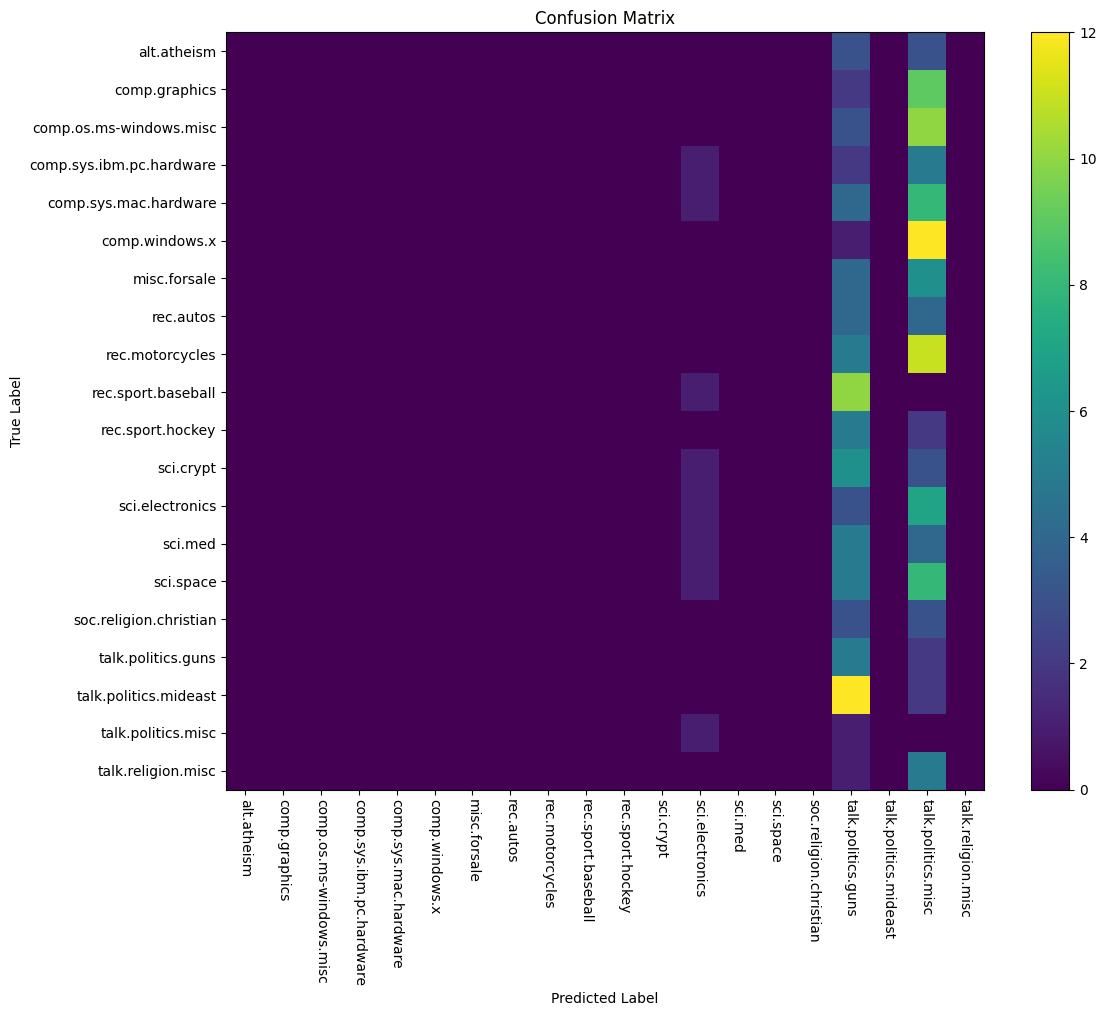

Confusion matrix for llama3.2:


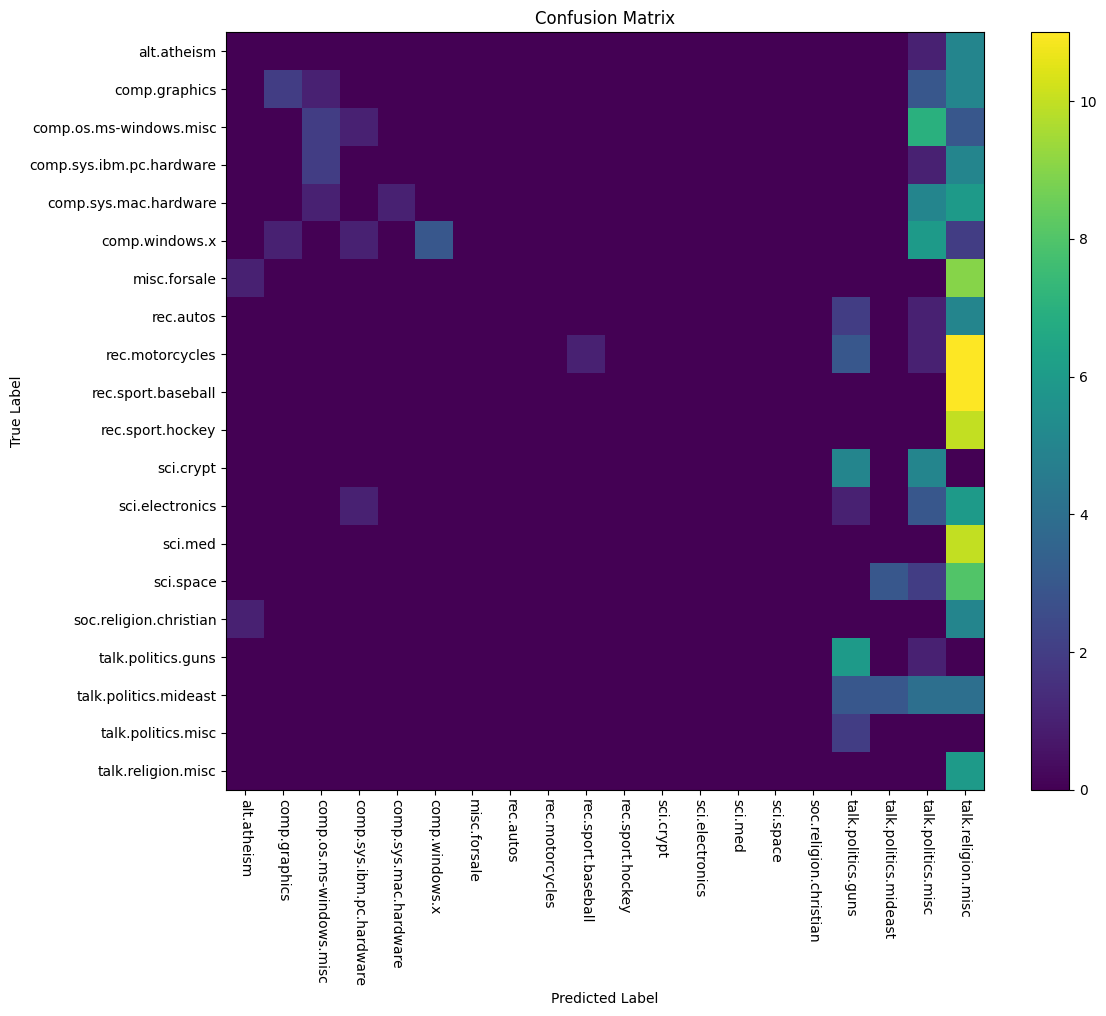

Confusion matrix for gemma3:1b:


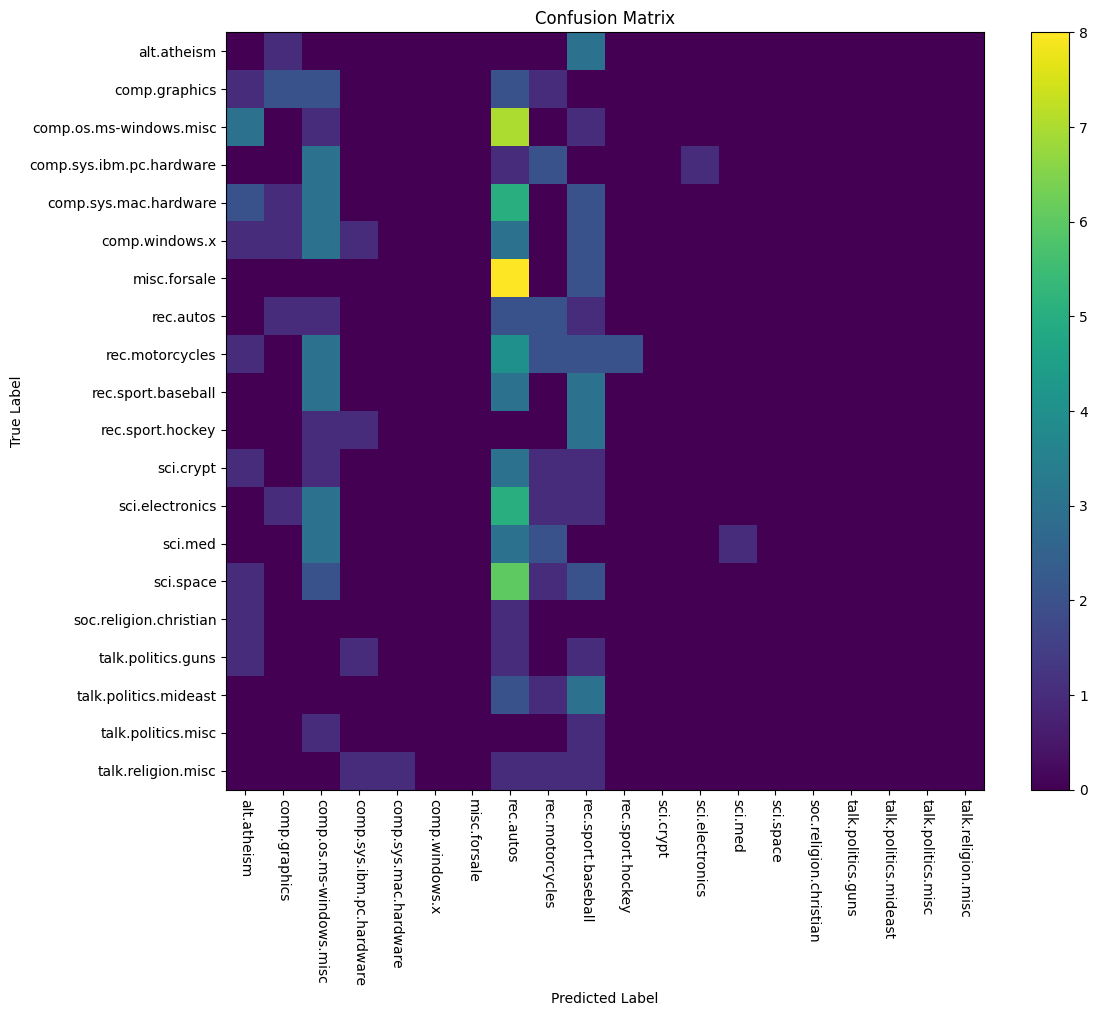

Confusion matrix for gemma3:4b:


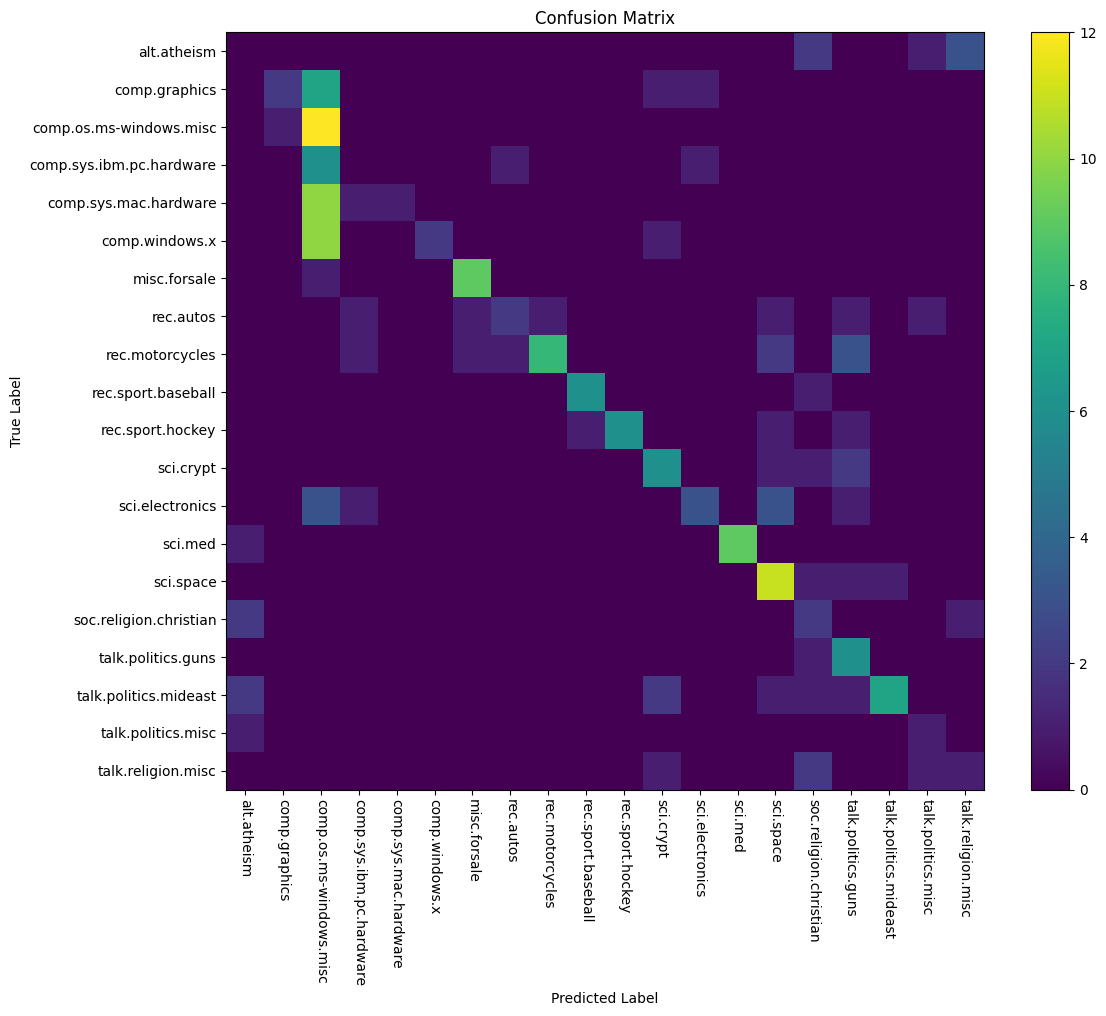

In [7]:
confusion_matrices = dict()
print(classification_data.columns)

for model in models:
    column_name = "predictions_" + model

    confusion_matrices[model] = part1_1_cm(
        classification_data,
        column_name
    )
    print(f"Confusion matrix for {model}:")
    part_1_1_vis(confusion_matrices[model])


★ Make sure the images are rendered in the notebook pdf you submit.

★ For each of the different classifiers, which pair of classes is most often confused?   

  For llama3.2:1b, the most common confusion is comp.windows.x being classified as talk.politics.misc, occurring 12 times.  
  For llama3.2, the most common confusion is rec.sport.baseball being classified as talk.religion.misc, occurring 11 times.  
  For gemma3:1b, the most common confusion is misc.forsale being classified as rec.autos, occurring 7 times.  
  For gemma3:4b, there is a tie: both comp.sys.mac.hardware and comp.windows.x are classified as comp.os.ms-windows.misc 11 times.  

★ Use the scratch space below to explore the documents that are misclassified most often with these class pairings, and include snippets of a few examples below.

★ Why might these pairs of classes be more difficult for the classifiers to distinguish?  

The most frequent errors for the smaller models appear to be caused more by label bias than by actual class similarity. The misclassified Llama examples are clearly about X11 or baseball, even though they are predicted as politics or religion, and Gemma 3 1B also predicts rec.autos for unrelated sale advertisements. This suggests that the smaller models sometimes collapse onto a few labels.  

The Gemma 3 4B errors are more reasonable because the computer related classes share a lot of vocabulary about hardware, displays, operating systems, and configuration. comp.windows.x is especially easy to confuse with comp.os.ms-windows.misc because both contain the word “windows,” although they refer to different systems.

In [8]:
# TODO: Use this scratch space to find documents
# that are examples of common misclassifications
def show_examples(data, model, true_label, predicted_label, n=3):
    column_name = "predictions_" + model
    count = 0

    for i in range(len(data)):
        true = data.iloc[i]["newsgroup"]
        predicted = normalize_prediction(data.iloc[i][column_name])

        if true == true_label and predicted == predicted_label:
            text = data.iloc[i]["text"]
            text = text.replace("\n", " ")

            print("Example", count + 1)
            print("True:", true)
            print("Predicted:", predicted)
            print(text[:500])
            print()

            count += 1
            if count == n:
                break

In [9]:
show_examples(
    classification_data,
    "llama3.2:1b",
    "comp.windows.x",
    "talk.politics.misc"
)

Example 1
True: comp.windows.x
Predicted: talk.politics.misc
From: tim@kimba.catt.citri.edu.au (Tim Liddelow) Subject: Installing MIT X11R5 on Apollo Organization: CATT Centre at CITRI, Melbourne, Australia Lines: 14  Can any Apollo GURUS out there let me know of their experiences building MIT X11R5, with or without GCC 2.3.3.  In particular, is there anything I should watch out for.  Thanks in advance  --tim  ________________________________________________________________________________   Tim Liddelow                                          for(;;) fo

Example 2
True: comp.windows.x
Predicted: talk.politics.misc
From: dnh@mfltd.co.uk (Des Herriott) Subject: XDM/xsession woes Keywords: xdm, xterm Lines: 22 Reply-To: dnh@mfltd.co.uk Organization: Micro Focus Ltd. X-Newsreader: mxrn 6.18-3   I've just managed to get xdm running from an NCR 3000 (an SVR4 486 box running XFree86 1.2) to my NCD XDisplay.  It's pretty much working, but I'm encountering a weird error.  I'm attempting to st

In [10]:
show_examples(
    classification_data,
    "llama3.2",
    "rec.sport.baseball",
    "talk.religion.misc"
)

Example 1
True: rec.sport.baseball
Predicted: talk.religion.misc
From: thf2@kimbark.uchicago.edu (Ted Frank) Subject: Re: MLB Standings and Scores for Fri., Apr. 16th, 1993 Keywords: mlb, 04.16 Reply-To: thf2@midway.uchicago.edu Organization: University of Chicago Lines: 23  In article <1qmj6h$m5h@agate.berkeley.edu> jtchern@ocf.berkeley.edu (Joseph Hernandez) writes: >Houston Astros		1		Seattle Mariners	1 >Montreal Expos		2		Toronto Blue Jays	3 >New York Mets		3		Oakland Athletics	2 >Colorado Rockies	5		Detroit Tigers		3 >Pittsburgh Pirates	5		Kansas City Ro

Example 2
True: rec.sport.baseball
Predicted: talk.religion.misc
From: cs1442aq@news.uta.edu (cs1442aq) Subject: Ryam out for 2-5 weeks!! Organization: University of Texas at Arlington Lines: 4  Nolan Ryan has torn cartlidge inhis right knee.  Is having surgery and is expected to miss 2-5 weeks.   --   

Example 3
True: rec.sport.baseball
Predicted: talk.religion.misc
From: kmelcher@rafael.Arco.COM (Kenneth Melcher) Subject: Re: 

In [11]:
show_examples(
    classification_data,
    "gemma3:1b",
    "misc.forsale",
    "rec.autos"
)

Example 1
True: misc.forsale
Predicted: rec.autos
From: lorne@sun.com (Lorne R. Johnson - Sun IC Region SE) Subject: WARRIORS TICKETS FOR SALE Organization: Sun Microsystems, Inc. Lines: 22 Distribution: ca Reply-To: lorne@sun.com NNTP-Posting-Host: normajean.west.sun.com      *****************************    * WARRIORS TICKETS FOR SALE *    *****************************  I have 2 tickets that I can't use (Last pair this year).  Section 109, Row P, Seats 8 & 9  DAY	DATE	OPPONENT	TIME	 ---	----	--------	----	 WED     4/21    Sacremento     7:30 

Example 2
True: misc.forsale
Predicted: rec.autos
From: erc@plitvice.berkeley.edu (Eric Ng) Subject: Sega Genesis plus 9 sports games for sale Nntp-Posting-Host: plitvice.berkeley.edu Organization: University of California at Berkeley Distribution: usa Lines: 23  FOR SALE  	1 Sega Genesis (including all cables, manuals, boxes) 	1 controller 	9 games, including all manuals and boxes: 		Sonic the Hedgehog 		Road Rash 		John Madden Football '92 		

In [12]:
show_examples(
    classification_data,
    "gemma3:4b",
    "comp.sys.mac.hardware",
    "comp.os.ms-windows.misc"
)

show_examples(
    classification_data,
    "gemma3:4b",
    "comp.windows.x",
    "comp.os.ms-windows.misc"
)

Example 1
True: comp.sys.mac.hardware
Predicted: comp.os.ms-windows.misc
From: petrack@vnet.IBM.COM Subject: disabling all power management interrupts Reply-To: petrack@vnet.IBM.COM Disclaimer: This posting may contain no views at all News-Software: Usenet 3.1 Lines: 21  Could someone please do one of the following: 1. Point to an init that allows me to turn off power management on my    Duo 210. 1. Write an init that would allow me to turn off ALL power management on    Duo 210. 2. Point me to documentation on power management so that I can write such    an init. 3.

Example 2
True: comp.sys.mac.hardware
Predicted: comp.os.ms-windows.misc
From: kuan@netcom.com (Kuan) Subject: Video Display Organization: Netcom Online Communications Services (408-241-9760 login: guest) Lines: 34      My mac monitor displays about 20 vertical lines when I use it. It means that either my display memory goes wrong or monitor is bad or video card is bad.    I checked my monitor, it works fine with other Ma

### Part 1.2: Accuracy (5 points)
Complete the following function, then use it to compute and compare the accuracies of each classifier.

Model predictions are raw text, not clean labels. Pass each one through
`normalize_prediction` (defined in Part 1.0) before comparing it to the ground
truth, and do it consistently across Parts 1.1 through 1.5 -- comparing the raw
strings scores at least one of these models far below its real accuracy.

A prediction that is still not one of the labels after normalising counts as
incorrect in Parts 1.2 through 1.5. Part 1.1 is the exception: a confusion
matrix has no cell to put it in, so it is left out of the counts there.

★ Generate a table comparing the accuracy of each of the classifier systems.

★ Which one has the highest accuracy?

In [13]:
def part1_2_acc(x: DataFrame, y: str) -> float:
    column_name = "predictions_" + y
    correct = 0

    for i in range(len(x)):
        true_label = x.iloc[i]["newsgroup"]
        prediction = normalize_prediction(x.iloc[i][column_name])

        if prediction == true_label:
            correct += 1

    accuracy = correct / len(x)
    return accuracy

accuracies: dict[str, float] = dict()

for model in models:
    accuracies[model] = part1_2_acc(classification_data, model)

save_results(accuracies, "results/accuracies.json")

accuracy_table = pd.DataFrame(
    list(accuracies.items()),
    columns=["Model", "Accuracy"]
)

print(accuracy_table)

best_model = "gemma3:4b" # TODO: Which model performed the best?

         Model  Accuracy
0  llama3.2:1b     0.030
1     llama3.2     0.115
2    gemma3:1b     0.055
3    gemma3:4b     0.470


### Part 1.3: Precision (5 points)
Complete the following function that returns, for each class, the precision of the classifier's labels given ground-truth labels. (note: if there are no predictions for a given class, then precision should be 0)

★ Generate a table showing, for the best-performing classifier, the precision of its labels across each class.

★ For which class are its labels the most accurate? The least?  

The highest precision is 1.0, achieved by sci.med, talk.politics.mideast, comp.sys.mac.hardware, rec.sport.hockey, and comp.windows.x. The lowest precision is 0.0 for comp.sys.ibm.pc.hardware, alt.atheism, and talk.religion.misc.

In [14]:
def part1_3_prec(x: DataFrame, y: str) -> dict[str, float]:
    column_name = "predictions_" + y
    precision = {}

    for label in labels:
        correct = 0
        predicted_count = 0

        for i in range(len(x)):
            true_label = x.iloc[i]["newsgroup"]
            prediction = normalize_prediction(x.iloc[i][column_name])

            if prediction == label:
                predicted_count += 1
                if true_label == label:
                    correct += 1

        if predicted_count == 0:
            precision[label] = 0
        else:
            precision[label] = correct / predicted_count

    return precision

if best_model not in models:
    print(f"best_model is still {best_model!r}. Set it in Part 1.2 to one of {models}, "
          f"then re-run this cell.")
    best_model_prec = None
else:
    best_model_prec = part1_3_prec(classification_data, best_model)

save_results(best_model_prec, "results/best_model_prec.json")

precision_table = pd.DataFrame(
    best_model_prec.items(),
    columns=["Class", "Precision"]
)

print(precision_table)

# TODO: Scratch space for analyzing the precision.

                       Class  Precision
0                    sci.med   1.000000
1                  rec.autos   0.500000
2            rec.motorcycles   0.888889
3            sci.electronics   0.600000
4      talk.politics.mideast   0.875000
5   comp.sys.ibm.pc.hardware   0.000000
6    comp.os.ms-windows.misc   0.244898
7         talk.politics.misc   0.250000
8      comp.sys.mac.hardware   1.000000
9         rec.sport.baseball   0.857143
10                 sci.crypt   0.545455
11                 sci.space   0.550000
12             comp.graphics   0.666667
13               alt.atheism   0.000000
14    soc.religion.christian   0.181818
15          rec.sport.hockey   1.000000
16            comp.windows.x   1.000000
17        talk.religion.misc   0.200000
18        talk.politics.guns   0.375000
19              misc.forsale   0.818182


### Part 1.4: Recall (5 points)
Complete the following function that returns, for each target class, the recall of the classifier's labels. (note: if there are no ground truth labels for a given class, the recall should be 0)

★ Generate a table showing, for each target class, the recall of the best-performing model's labels across each class.

★ For which class is recall the highest? The lowest?  

The highest recall is achieved by comp.os.ms-windows.misc, with a recall of approximately 0.923. The lowest recall is 0.0, shared by comp.sys.ibm.pc.hardware, alt.atheism, and talk.religion.misc.

In [15]:
def part1_4_rec(x: DataFrame, y: str) -> dict[str, float]:
    column_name = "predictions_" + y
    recall = {}

    for label in labels:
        correct = 0
        true_count = 0

        for i in range(len(x)):
            true_label = x.iloc[i]["newsgroup"]
            prediction = normalize_prediction(x.iloc[i][column_name])

            if true_label == label:
                true_count += 1
                if prediction == label:
                    correct += 1

        if true_count == 0:
            recall[label] = 0
        else:
            recall[label] = correct / true_count

    return recall
if best_model not in models:
    print(f"best_model is still {best_model!r}. Set it in Part 1.2 to one of {models}, "
          f"then re-run this cell.")
    best_model_rec = None
else:
    best_model_rec = part1_4_rec(classification_data, best_model)

save_results(best_model_rec, "results/best_model_rec.json")

recall_table = pd.DataFrame(
    best_model_rec.items(),
    columns=["Class", "Recall"]
)

print(recall_table)


# TODO: Scratch space for analyzing the recall.

                       Class    Recall
0                    sci.med  0.900000
1                  rec.autos  0.250000
2            rec.motorcycles  0.500000
3            sci.electronics  0.272727
4      talk.politics.mideast  0.500000
5   comp.sys.ibm.pc.hardware  0.000000
6    comp.os.ms-windows.misc  0.923077
7         talk.politics.misc  0.500000
8      comp.sys.mac.hardware  0.076923
9         rec.sport.baseball  0.545455
10                 sci.crypt  0.600000
11                 sci.space  0.785714
12             comp.graphics  0.181818
13               alt.atheism  0.000000
14    soc.religion.christian  0.333333
15          rec.sport.hockey  0.545455
16            comp.windows.x  0.153846
17        talk.religion.misc  0.166667
18        talk.politics.guns  0.857143
19              misc.forsale  0.900000


### Part 1.5: F1 (5 points)

A weighted average F1 score computes an average F1 score over all target classes, weighted by the true number of instances of that class:

![test](https://github.com/zinengtang/cs183-fall26-a1/blob/main/A1_Data/f1.png?raw=1)

Here, *f* is a classification function, *C* is the set of classes, *D* is the set of evaluation data with ground-truth labels, and *D_c* is the set of data whose ground-truth label is *c*.

Implement two functions below:
* A function that returns, for a target class, the F1 of a classifier's labels given ground truth labels
* A function that uses the previous function to compute a weighted average F1 score

In [16]:
def part1_5_class_f1(x: DataFrame, y: str, z: str) -> float:
    # TODO: Implement this function
    # note: z is the class we want to compute F1 for, and y is the model name string
    column_name = "predictions_" + y
    true_positive = 0
    false_positive = 0
    false_negative = 0

    for i in range(len(x)):
        true_label = x.iloc[i]["newsgroup"]
        prediction = normalize_prediction(x.iloc[i][column_name])

        if prediction == z and true_label == z:
            true_positive += 1
        elif prediction == z and true_label != z:
            false_positive += 1
        elif prediction != z and true_label == z:
            false_negative += 1

    precision_denominator = true_positive + false_positive
    recall_denominator = true_positive + false_negative

    if precision_denominator == 0:
        precision = 0
    else:
        precision = true_positive / precision_denominator

    if recall_denominator == 0:
        recall = 0
    else:
        recall = true_positive / recall_denominator

    if precision + recall == 0:
        return 0

    f1 = 2 * precision * recall / (precision + recall)
    return f1

def part1_5_weighted_f1(x: DataFrame, y: str) -> float:
    # TODO: Implement this function
    weighted_sum = 0

    for label in labels:
        class_count = 0

        for i in range(len(x)):
            if x.iloc[i]["newsgroup"] == label:
                class_count += 1

        class_f1 = part1_5_class_f1(x, y, label)

        weighted_sum += class_f1 * class_count

    weighted_f1 = weighted_sum / len(x)

    return weighted_f1

★ Generate a table comparing the weighted F1 score of each classifier.

★ Which is the best classifier according to weighted F1? How and why might this differ from an accuracy comparison (Part 1.2)?  

gemma3:4b has the highest weighted F1 score. This can differ from accuracy because accuracy only measures the overall proportion of correct predictions, while F1 considers both precision and recall for each class. Weighted F1 therefore also reflects how well the classifier balances false positives and false negatives across classes.

In [17]:
f1s: dict[str, float] = dict()

for model in models:
    f1s[model] = part1_5_weighted_f1(classification_data, model)

save_results(f1s, "results/f1s.json")

f1_table = pd.DataFrame(
    f1s.items(),
    columns=["Model", "Weighted F1"]
)

print(f1_table)

best_f1_model = max(f1s, key=f1s.get)

print("Best classifier:", best_f1_model)
print("Weighted F1:", f1s[best_f1_model])

# TODO: Scratch space for analyzing and reporting the F1.

         Model  Weighted F1
0  llama3.2:1b     0.009636
1     llama3.2     0.101619
2    gemma3:1b     0.045715
3    gemma3:4b     0.470887
Best classifier: gemma3:4b
Weighted F1: 0.4708872896239029


## Part 2: Automatic speech recognition (25 points)
Here, we'll explore using a popular open-source automatic speech recognition system to compare its performance across English speakers whose native language differs.

### Part 2.0: Setup
`transcriptions.tsv` ships with the repo, so the cell below only downloads the Speech Accent Archive (https://www.kaggle.com/datasets/rtatman/speech-accent-archive/data) -- an 865MB archive that takes a while to extract -- when those transcripts are missing or incomplete.

In [18]:
import os

# transcriptions.tsv ships with the repo. The 865MB audio archive is only needed
# when it is missing or short, so decide that first and skip the download otherwise.
transcript_counts = {}
if os.path.exists('transcriptions.tsv'):
    with open('transcriptions.tsv') as infile:
        for line in infile:
            language, _, _ = line.rstrip("\n").partition("\t")
            transcript_counts[language] = transcript_counts.get(language, 0) + 1

need_to_transcribe = not transcript_counts or any(n != 20 for n in transcript_counts.values())

if need_to_transcribe:
    import kagglehub
    speech_accent_path = kagglehub.dataset_download("rtatman/speech-accent-archive")
    speakers = pd.read_csv(f"{speech_accent_path}/speakers_all.csv")
    language_counts = speakers['native_language'].value_counts()
    languages_with_over_20_samples = set(language_counts[language_counts >= 20].index)
else:
    languages_with_over_20_samples = set(transcript_counts)

print(f"{len(languages_with_over_20_samples)} languages with at least 20 samples:")
print(sorted(languages_with_over_20_samples))

21 languages with at least 20 samples:
['amharic', 'arabic', 'cantonese', 'dutch', 'english', 'farsi', 'french', 'german', 'italian', 'japanese', 'korean', 'macedonian', 'mandarin', 'polish', 'portuguese', 'romanian', 'russian', 'spanish', 'swedish', 'turkish', 'vietnamese']


If the transcripts do need regenerating, load WhisperX. This might take some time to load.

In [19]:
if need_to_transcribe:
    import whisperx

    # Needs whisperx >= 3.8: 3.4.2 could not load its own VAD against current
    # pyannote-audio, and it also caps out at Python 3.12, which Colab is past.
    whisperx_model = whisperx.load_model("tiny", "cpu", compute_type="float32", language="en")

Now let's run inference. This is the smallest model we could run inference on, so its performance isn't going to be great. But, it shouldn't take *too* long to run on your local machine!

In [20]:
from tqdm import tqdm

transcriptions = {language: list() for language in languages_with_over_20_samples}

if need_to_transcribe:
    recordings_filepath = f"{speech_accent_path}/recordings/recordings/"
    for language in languages_with_over_20_samples:
        print(f"Transcribing for native language {language}...")
        for i in tqdm(range(20)):
            filename = f"{language}{i + 1}.mp3"
            audio = whisperx.load_audio(f"{recordings_filepath}/{filename}")
            transcription = whisperx_model.transcribe(audio, language="en")
            # flatten to text here, so this path and the tsv path agree on the type
            text = " ".join(segment["text"] for segment in transcription["segments"])
            transcriptions[language].append(" ".join(text.split()))

    with open("transcriptions.tsv", "w") as ofile:
        for language, transcripts in transcriptions.items():
            for transcript in transcripts:
                ofile.write(f"{language}\t{transcript}\n")
else:
    with open('transcriptions.tsv') as infile:
        for line in infile:
            # partition rather than split so an empty transcript is still a valid row
            language, _, transcript = line.rstrip("\n").partition("\t")
            if language in transcriptions:
                transcriptions[language].append(transcript)

### Part 2.1: Word error rate (10 points)
Implement the following function to compute the word error rate of a candidate transcription against a reference. It takes the **reference** first and the candidate second, matching the call below. Each of the recordings we transcribed are readings of the same English text: *"Please call Stella.  Ask her to bring these things with her from the store:  Six spoons of fresh snow peas, five thick slabs of blue cheese, and maybe a snack for her brother Bob.  We also need a small plastic snake and a big toy frog for the kids.  She can scoop these things into three red bags, and we will go meet her Wednesday at the train station."*

Compare the two token lists case-insensitively. Whether a transcript writes
*Please* or *please* is a choice the ASR system made about how to render the
words it heard, not a recognition error, so folding case keeps the metric
measuring what it is supposed to measure.

In [21]:
def part2_1(x: list[str], y: list[str]) -> float:
    # TODO: Implement this function.
    # note: x is the tokenised reference and y is the tokenised candidate.
    # The word error rate is normalised by the length of the reference, so
    # getting these the wrong way round gives a plausible-looking wrong answer.
    # compare case-insensitively
    x2 = []
    y2 = []

    for w in x:
        x2.append(w.lower())
    for w in y:
        y2.append(w.lower())

    n = len(x2)
    m = len(y2)

    dp = []
    for i in range(n + 1):
        dp.append([0] * (m + 1))

    for i in range(n + 1):
        dp[i][0] = i
    for j in range(m + 1):
        dp[0][j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if x2[i - 1] == y2[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]
            else:
                sub = dp[i - 1][j - 1] + 1
                delete = dp[i - 1][j] + 1
                insert = dp[i][j - 1] + 1
                dp[i][j] = min(sub, delete, insert)

    if n == 0:
        return 0.0

    return dp[n][m] / n

Then let's evaluate for all of the candidate transcriptions and each of the native languages.

★ Generate a table comparing the average WER across each of the languages.

In [22]:
import nltk
nltk.download('punkt_tab')

reference = "Please call Stella.  Ask her to bring these things with her from the store: " \
            "Six spoons of fresh snow peas, five thick slabs of blue cheese, and maybe a snack " \
            "for her brother Bob.  We also need a small plastic snake and a big toy frog for the kids. " \
            "She can scoop these things into three red bags, and we will go meet her Wednesday at the "\
            "train station."

language_wers = {language: list() for language in languages_with_over_20_samples}
for language, transcripts in transcriptions.items():
    for candidate in transcripts:
        language_wers[language].append(part2_1(nltk.word_tokenize(reference), nltk.word_tokenize(candidate)))

save_results(language_wers, "results/language_wers.json")

# TODO: Scratch space for computing average WER and generating a table to compare across native languages.
avg_wers = {}

for lang in language_wers:
    vals = language_wers[lang]
    avg_wers[lang] = sum(vals) / len(vals)

wer_table = pd.DataFrame(
    avg_wers.items(),
    columns=["Native Language", "Average WER"]
)

wer_table = wer_table.sort_values("Average WER")
print(wer_table)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


   Native Language  Average WER
16          german     0.083766
9          english     0.085714
0       macedonian     0.092857
10         swedish     0.101299
11        romanian     0.109091
6            dutch     0.114286
2            farsi     0.114286
18          polish     0.131169
4         japanese     0.133117
15          french     0.140260
5           arabic     0.141558
13         italian     0.151948
17      portuguese     0.160390
19         russian     0.161039
12        mandarin     0.166883
20          korean     0.172727
14       cantonese     0.175325
8          turkish     0.186364
7          spanish     0.221429
3          amharic     0.227273
1       vietnamese     0.266234


### Part 2.2: Confidence intervals (10 points)

Each average WER you just computed comes from 20 recordings. Twenty *different*
speakers of the same native language would have given you a different average.
Before ranking the languages, you need to know how much that number moves.

You cannot collect more recordings, but you can estimate the spread from the
sample you already have. Draw 20 values *with replacement* from a language's 20
WERs and average them; that is one plausible alternative sample. Repeat it many
times and the middle 95% of those averages is a 95% confidence interval for the
mean.

Implement the function below. `x` is the list of WER values for one language and
`y` is how many times to resample; return the lower and upper bounds of the 95%
interval.

In [23]:
def part2_2_ci(x: list[float], y: int = 10000) -> tuple[float, float]:
    # TODO: Implement this function.
    means = []

    for i in range(y):
        sample = np.random.choice(x, size=len(x), replace=True)
        means.append(np.mean(sample))

    low = np.percentile(means, 2.5)
    high = np.percentile(means, 97.5)

    return float(low), float(high)

language_wer_cis = dict()
for language, wers in language_wers.items():
    language_wer_cis[language] = part2_2_ci(wers)

save_results(language_wer_cis, "results/language_wer_cis.json")

# TODO: Scratch space for adding the intervals to your Part 2.1 table.

rows = []

for lang in avg_wers:
    avg = avg_wers[lang]
    low, high = language_wer_cis[lang]
    rows.append([lang, avg, low, high])

wer_table = pd.DataFrame(
    rows,
    columns=["Native Language", "Average WER", "CI Low", "CI High"]
)

wer_table = wer_table.sort_values("Average WER")
print(wer_table)

   Native Language  Average WER    CI Low   CI High
16          german     0.083766  0.067532  0.101299
9          english     0.085714  0.063636  0.111688
0       macedonian     0.092857  0.072727  0.116883
10         swedish     0.101299  0.075974  0.135065
11        romanian     0.109091  0.088961  0.131818
6            dutch     0.114286  0.092208  0.138312
2            farsi     0.114286  0.086364  0.148701
18          polish     0.131169  0.096753  0.168182
4         japanese     0.133117  0.102597  0.166883
15          french     0.140260  0.108442  0.172078
5           arabic     0.141558  0.118182  0.168182
13         italian     0.151948  0.120130  0.188312
17      portuguese     0.160390  0.105195  0.238312
19         russian     0.161039  0.120779  0.206494
12        mandarin     0.166883  0.133766  0.201948
20          korean     0.172727  0.130519  0.216883
14       cantonese     0.175325  0.131169  0.226623
8          turkish     0.186364  0.126623  0.265584
7          s

★ Extend your table from Part 2.1 with each language's confidence interval.

★ You named the lowest-WER languages in Part 2.1. Taking the intervals into
account, which of those are actually distinguishable from one another, and which
are not?  

The lowest-WER languages are German (0.084), English (0.086), Macedonian (0.093), Swedish (0.101), and Romanian (0.109). Their confidence intervals overlap quite a lot, so I would not say any of these are clearly distinguishable from each other based on this sample. For example, German has a 95% CI of about [0.068, 0.101], while English is [0.064, 0.112] and Macedonian is [0.072, 0.117]. Even though their average WERs are slightly different, the uncertainty is large enough that the ordering could easily change with another set of speakers.

★ Some pairs of languages *are* clearly separated. What is different about those
pairs, compared to the ones you cannot separate?

The clearly separated pairs have a much bigger gap in average WER compared with the width of their confidence intervals. For example, German has an average WER of about 0.084 with CI [0.068, 0.101], while Vietnamese has an average WER of about 0.266 with CI [0.200, 0.339]. Those intervals do not overlap at all. The pairs that are hard to separate usually have very similar average WERs and a lot of overlap between their intervals.

★ What would you need in order to separate the languages whose intervals
currently overlap?  

We would mainly need more recordings from more independent speakers for each language. Right now there are only 20 speakers per language, so the estimated mean WER still has a fair amount of uncertainty. With a larger sample, the confidence intervals would usually get narrower, which would make it easier to tell whether small differences between languages are actually meaningful.

### Part 2.3: Error analysis (5 points)
★ Which languages have the lowest WER? Which have the highest?  

German has the lowest average WER at about 0.084, followed by English (0.086), Macedonian (0.093), Swedish (0.101), and Romanian (0.109). On the other end, Vietnamese has the highest WER at about 0.266, followed by Amharic (0.227) and Spanish (0.221).  

★ Why might these languages have lower WER?  

English being near the top makes sense because the ASR model is recognizing English speech, so native English pronunciation should generally be easier for it. Some of the other low-WER languages, such as German and Swedish, may also have pronunciation patterns or sounds that are relatively close to English. Another possibility is that the ASR model has seen more speech from some accents during training than others. So I would not treat the ranking as purely a property of the languages themselves; it could also reflect the speakers in this dataset and the model's training data.  

★ Which of the differences you just described survive the confidence intervals
from Part 2.2, and which are within the noise?  

The differences among the lowest-WER languages are mostly within the noise. German, English, Macedonian, Swedish, and Romanian all have substantially overlapping confidence intervals, so their exact ordering is not very convincing. The same is true for the highest-WER group: Vietnamese, Amharic, and Spanish have overlapping intervals, so we cannot confidently say that one of those accents is harder than the others based on these 20 speakers.

Larger gaps are much more convincing. For example, German's CI is about [0.068, 0.101], while Vietnamese's is [0.200, 0.339], so those are clearly separated. German is also separated from languages such as Japanese ([0.103, 0.166]) and Arabic ([0.118, 0.167]). So the broad difference between some low-WER and high-WER languages survives the confidence intervals, while many of the smaller differences between neighboring languages are basically within the sampling noise.

## Part 3: Machine translation (25 points)
In this part we will evaluate models on their abilities to translate text via BLEU score.

### Part 3.0: Setup


Prepare the dataset we will use for evaluation. These are the Czech, Chinese and Gujarati halves of the standard WMT19 into-English translation sets. We will just use the first 25 examples of each for evaluation.

In [24]:
from datasets import load_dataset
from itertools import islice

# streaming=True reads only the validation shards. Without it, load_dataset also
# materialises every training split -- 7.3M cs-en rows, 26M zh-en rows, ~13GB of
# HuggingFace cache -- to reach the 75 sentences we actually evaluate on.
hf_dataset_cs = load_dataset("wmt/wmt19", "cs-en", split="validation", streaming=True)
hf_dataset_zh = load_dataset("wmt/wmt19", "zh-en", split="validation", streaming=True)
hf_dataset_gu = load_dataset("wmt/wmt19", "gu-en", split="validation", streaming=True)

dataset_items_cs = []
for i, item in enumerate(islice(hf_dataset_cs, 25)):
    dataset_items_cs.append({
        'id': i,
        'czech_text': item['translation']['cs'],
        'english_text': item['translation']['en']
    })

dataset_items_zh = []
for i, item in enumerate(islice(hf_dataset_zh, 25)):
    dataset_items_zh.append({
        'id': i,
        'chinese_text': item['translation']['zh'],
        'english_text': item['translation']['en']
    })

dataset_items_gu = []
for i, item in enumerate(islice(hf_dataset_gu, 25)):
    dataset_items_gu.append({
        'id': i,
        'gujarati_text': item['translation']['gu'],
        'english_text': item['translation']['en']
    })

dataset_cs = pd.DataFrame(dataset_items_cs)
dataset_zh = pd.DataFrame(dataset_items_zh)
dataset_gu = pd.DataFrame(dataset_items_gu)
print(f"Loaded translation data of shape {dataset_cs.shape} with columns {dataset_cs.columns.tolist()}.")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Loaded translation data of shape (25, 3) with columns ['id', 'czech_text', 'english_text'].


We will use a simple nltk based tokenizer to encode the n-gram tokens for computing the bleu score.

In [25]:
import nltk
from nltk.tokenize import word_tokenize

def tokenize_text(text):
    # Download required NLTK data if not already downloaded
    try:
        nltk.data.find('tokenizers/punkt_tab')
    except LookupError:
        nltk.download('punkt_tab')

    # Tokenize the text into a list of tokens
    tokens = word_tokenize(text)
    return tokens


In [26]:
tokenize_text("Welcome to CS-183: we are learning about NLP evaluations today!!!")

['Welcome',
 'to',
 'CS-183',
 ':',
 'we',
 'are',
 'learning',
 'about',
 'NLP',
 'evaluations',
 'today',
 '!',
 '!',
 '!']

In [27]:
dataset_cs.head()

,id,czech_text,english_text
0,0,Hnutí za občanská práva vydalo cestovní výstra...,Civil rights group issues travel warning for M...
1,1,Národní asociace pro zvýhodňování barevných li...,The National Association for the Advancement o...
2,2,"„Cestovní doporučení NAACP pro stát Missouri, ...","""The NAACP Travel Advisory for the state of Mi..."
3,3,"NAACP uvedlo, že k tomuto kroku přistoupilo na...",A recent Missouri law making it harder for peo...
4,4,„Dochází k porušování občanských práv.,"""You have violations of civil rights that are ..."


In [28]:
dataset_zh.head()

,id,chinese_text,english_text
0,0,上周，古装剧《美人私房菜》临时停播，意外引发了关于国产剧收视率造假的热烈讨论。,"Last week, the broadcast of period drama “Beau..."
1,1,民权团体针对密苏里州发出旅行警告,Civil rights group issues travel warning for M...
2,2,由于密苏里州的歧视性政策和种族主义袭击，美国有色人种促进协会 (NAACP) 向准备前往密苏...,The National Association for the Advancement o...
3,3,“2017 年 8 月 28 日生效的 NAACP 密苏里州旅行咨询中呼吁，因近期密苏里州发...,"""The NAACP Travel Advisory for the state of Mi..."
4,4,NAACP 指出，最近通过的一项密苏里州法律使得人们更难赢得歧视诉讼，该州执法也一定程度上针...,A recent Missouri law making it harder for peo...


In [29]:
dataset_gu.head()

,id,gujarati_text,english_text
0,0,બેરિયર ભાંગી ગયા પછી સેન્ટ્રલ પાર્કમાં હજારો ગ...,Thousands in Central Park panic after barrier ...
1,1,એક રાજકીય કાર્યક્રમમાં પોલીસ બેરીયરના ભંગાણને ...,The collapse of a police barrier sent thousand...
2,2,ડેમોક્રેટિક ન્યૂયોર્ક સરકારની મોટી નામી હસ્તીઓ...,Big-name personalities from Democratic New Yor...
3,3,શનિવારે સાંજે બેરીયર પડ્યા પછી અધિકારીઓએ ટોળાન...,Authorities quickly assured the crowd they wer...
4,4,સામાજિક ન્યાયના સળગતા મુદ્દાઓએ તડકાની ખરા બપોર...,Burning social justice issues dominated the ev...


now let's get the model predictions for these translations

In [30]:
def get_translation_prompt(text, source_language):
	translation_prompt = f"Translate the following text from {source_language} to English. Output only the translation, no other text."
	translation_prompt += f"\n\nText:\n{text}"
	return translation_prompt

prompts_cs = [get_translation_prompt(text, "Czech") for text in dataset_cs["czech_text"]]
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt3_1_translation_data_cs", prompts_cs)
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=512)
	cache_inferences(model, "pt3_1_translation_data_cs", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt3_1_translation_data_cs", prompts_cs)
	dataset_cs[f"predictions_{model}"] = inferences

prompts_zh = [get_translation_prompt(text, "Chinese") for text in dataset_zh["chinese_text"]]
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt3_1_translation_data_zh", prompts_zh)
	print(f"Remaining prompts: {len(remaining_prompts)}")
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=512)
	cache_inferences(model, "pt3_1_translation_data_zh", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt3_1_translation_data_zh", prompts_zh)
	dataset_zh[f"predictions_{model}"] = inferences

prompts_gu = [get_translation_prompt(text, "Gujarati") for text in dataset_gu["gujarati_text"]]
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt3_1_translation_data_gu", prompts_gu)
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=512)
	cache_inferences(model, "pt3_1_translation_data_gu", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt3_1_translation_data_gu", prompts_gu)
	dataset_gu[f"predictions_{model}"] = inferences

Running inference for llama3.2:1b


0it [00:00, ?it/s]


Running inference for llama3.2


0it [00:00, ?it/s]


Running inference for gemma3:1b


...

0it [00:00, ?it/s]


Running inference for gemma3:1b


0it [00:00, ?it/s]


Running inference for gemma3:4b


0it [00:00, ?it/s]


In [31]:
dataset_cs

,id,czech_text,english_text,predictions_llama3.2:1b,predictions_llama3.2,predictions_gemma3:1b,predictions_gemma3:4b
0,0,Hnutí za občanská práva vydalo cestovní výstra...,Civil rights group issues travel warning for M...,Travel warning issued by the rights movement f...,Movement for Civil Rights issued a travel warn...,Committee for Civic Rights issued a travel war...,The Civil Rights Movement issued a travel warn...
1,1,Národní asociace pro zvýhodňování barevných li...,The National Association for the Advancement o...,National Association for the Advancement of Co...,National Association for the Advancement of Co...,The National Association for the Advancement o...,The National Association for the Advancement o...
2,2,"„Cestovní doporučení NAACP pro stát Missouri, ...","""The NAACP Travel Advisory for the state of Mi...",Travel advisories of the NAACP for the state o...,The NAACP travel advisory for the state of Mis...,“NAACP travel recommendation for the state of ...,“Travel recommendations from the NAACP for the...
3,3,"NAACP uvedlo, že k tomuto kroku přistoupilo na...",A recent Missouri law making it harder for peo...,They have taken this step based on the current...,The NAACP stated that it took this step based ...,The NAACP has stated that this step was taken ...,NAACP stated that it took this step based on t...
4,4,„Dochází k porušování občanských práv.,"""You have violations of civil rights that are ...","""Something is being destroyed.""",There is a violation of civil rights.,“He is violating citizens’ rights.”,Human rights are being violated.
5,5,Lidé jsou zastavováni policisty jen kvůli barv...,They're being pulled over because of their ski...,They are harassed by police just because of th...,People are stopped by police just because of t...,People are stopped by police only because of t...,“People are being stopped by police solely bec...
6,6,„Hromadí se nám dosud největší množství stížno...,"""We are hearing complaints at a rate we haven'...","""Despite our complaints, we still have the mos...",The complaints are mounting to the greatest ex...,We have so far received the largest amount of ...,“We are still accumulating the largest amount ...
7,7,"Jedná se o první varování svého druhu, které o...",It is the first such warning that the organiza...,"It is the first warning of its species, which ...",It is the first warning of its kind that the o...,"It is the first warning of our species, issued...",This is the first warning of its kind issued b...
8,8,"Mezi incidenty, které organizace citovala, byl...",The group cited incidents such as racial slurs...,racially motivated hate speech incidents cited...,"Among the incidents cited by the organization,...","During incidents cited by the organization, ra...",Among the incidents cited by the organizations...
9,9,Sanders zemřel za sporných okolností na začátk...,Sanders died under questionable circumstances ...,He died under suspicious circumstances at the ...,He died under disputed circumstances at the be...,Sanders died under suspicious circumstances at...,Sanders died under disputed circumstances at t...


In [32]:
dataset_zh

,id,chinese_text,english_text,predictions_llama3.2:1b,predictions_llama3.2,predictions_gemma3:1b,predictions_gemma3:4b
0,0,上周，古装剧《美人私房菜》临时停播，意外引发了关于国产剧收视率造假的热烈讨论。,"Last week, the broadcast of period drama “Beau...","Last week, the period drama ""Beautiful Private...","Last week, the costume drama ""Beauty and the F...","Last week, the temporary suspension of the his...","Last week, the costume drama ""Beauty's Private..."
1,1,民权团体针对密苏里州发出旅行警告,Civil rights group issues travel warning for M...,Travel warning issued by civil rights group ag...,Human rights groups issue travel warning for M...,Civil rights groups are issuing travel warning...,Civil rights groups have issued travel warning...
2,2,由于密苏里州的歧视性政策和种族主义袭击，美国有色人种促进协会 (NAACP) 向准备前往密苏...,The National Association for the Advancement o...,Due to the state's discriminatory policies and...,Due to discriminatory policies and racist atta...,Due to discriminatory policies and racial atta...,Due to discriminatory policies and racial atta...
3,3,“2017 年 8 月 28 日生效的 NAACP 密苏里州旅行咨询中呼吁，因近期密苏里州发...,"""The NAACP Travel Advisory for the state of Mi...","""NAACP密苏里州旅行咨询于2017年8月28日生效，要求所有非裔美国人、游客以及密苏里州...","The NAACP Travel Advisory for Missouri, effect...","“On August 28, 2017, the NAACP has issued a ca...","Issued on August 28, 2017, the NAACP’s Missour..."
4,4,NAACP 指出，最近通过的一项密苏里州法律使得人们更难赢得歧视诉讼，该州执法也一定程度上针...,A recent Missouri law making it harder for peo...,The NAACP has stated that a recent Missouri la...,The NAACP stated that a recent law passed in M...,The NAACP has pointed out that a recent law in...,The NAACP pointed out that a recently passed M...
5,5,侵犯公民权利的行为正发生在人们身上。,"""You have violations of civil rights that are ...",Violations of citizen rights are happening all...,The behavior that infringes on citizens' right...,Violations of human rights are happening right...,Actions violating citizens' rights are current...
6,6,他们因肤色被停车盘问，被殴打或被杀害，”密苏里州 NAACP 主席罗德·查培尔告诉堪萨斯城星...,They're being pulled over because of their ski...,They were stopped and beaten or killed by driv...,They were beaten or killed because of their sk...,“They were questioned about their skin color a...,"“They were stopped and questioned, beaten, or ..."
7,7,“我们收到了许多投诉，数量前所未有。”,"""We are hearing complaints at a rate we haven'...","""We have received many complaints, the number ...","""We have received many complaints, a number un...","We have received many complaints, the number i...","We have received a large number of complaints,..."
8,8,这是该组织在美国针对某个州发布的第一个此类警告。,It is the first such warning that the organiza...,This is the first warning issued by the organi...,This is the first of its kind warning issued b...,This is the first such warning issued by this ...,This is the first such warning issued by the o...
9,9,该组织援引了密苏里大学对黑人学生的种族诽谤以及 28 岁田纳西州黑人男性托利·桑德斯的死亡事件。,The group cited incidents such as racial slurs...,The organization cited the racist remarks made...,The organization cited the racial slurs direct...,The organization invoked the assistance of Mis...,This organization cited the Missouri Universit...


In [33]:
dataset_gu

,id,gujarati_text,english_text,predictions_llama3.2:1b,predictions_llama3.2,predictions_gemma3:1b,predictions_gemma3:4b
0,0,બેરિયર ભાંગી ગયા પછી સેન્ટ્રલ પાર્કમાં હજારો ગ...,Thousands in Central Park panic after barrier ...,"After being beaten, he ran into a thousand cro...","After the barrier was broken, thousands were i...",The potatoes collapsed and thousands of them w...,"After the barrier was broken, thousands panick..."
1,1,એક રાજકીય કાર્યક્રમમાં પોલીસ બેરીયરના ભંગાણને ...,The collapse of a police barrier sent thousand...,Thousands of people were trapped in fear of be...,Thousands of people were forced to take shelte...,“A central park was threatened with a deadly s...,A stampede in Central Park occurred after poli...
2,2,ડેમોક્રેટિક ન્યૂયોર્ક સરકારની મોટી નામી હસ્તીઓ...,Big-name personalities from Democratic New Yor...,The Democratic New York State Legislature has ...,Democratic New York government's prominent fig...,Democratic New York government’s large petitio...,Democratic New York state dignitaries Andrew C...
3,3,શનિવારે સાંજે બેરીયર પડ્યા પછી અધિકારીઓએ ટોળાન...,Authorities quickly assured the crowd they wer...,Gujarati to English translation:\nAs the day e...,After the Beriyar (a type of fruit) fell on Sa...,"On Saturday evening, after encountering obstac...","On Saturday evening, after the barrier was ere..."
4,4,સામાજિક ન્યાયના સળગતા મુદ્દાઓએ તડકાની ખરા બપોર...,Burning social justice issues dominated the ev...,Social justice movements have started to take ...,The phenomenon of social justice issues escala...,Social justice issues have brought about a cri...,The burning issues of social justice overshado...
5,5,"લગભગ 60,000 લોકોથી ગ્લોબલ સિટીઝન ફેસ્ટિવલ માટે...","About 60,000 people filled the park's Great La...",The main gate of the global city festival has ...,"The park was filled with almost 60,000 people ...",The park has become crowded with thousands of ...,The Great Lawn of the park was packed with alm...
6,6,કેટલાક સ્પીકરોએ પ્રેક્ષકોને સુપ્રીમ કોર્ટના નો...,Some speakers asked the audience to call their...,Some members of the opposition have expressed ...,Some speakers called upon their Congress party...,Some politicians asked their congress members ...,Some speakers asked their congressional member...
7,7,"બીજી ઓક્ટોબરથી અન્ના હજારે કરશે ભૂખ હડતાળ, PM ...",Anna Hazare will go on hunger strike from 2nd ...,He will write a letter to PM Modi from Annha.,"From October 2nd, Anna Hazare will start a hun...","Second October to half-past midnight, Prime Mi...",Anna Hazare will go on a hunger strike from Oc...
8,8,મહારાષ્ટ્ર: સામાજીક કાર્યકર્તા અન્ના હજારેએ બી...,Maharashtra: The social activist Anna Hazare h...,The social worker Annapoorna Hazare has filed ...,Maharashtra: Social activist Anna Hazare has a...,Maharashtra: The Social Workers Ananya have be...,Maharashtra: Social worker Anna Hazare has ann...
9,9,અન્ના હજારેએ વડાપ્રધાન પર પ્રહાર કરતા કહ્યું ક...,Anna Hazare has heavily criticized the Prime m...,Annaji has said that the government led by the...,Anna Hazare has said that the BJP-led governme...,"The Prime Minister was going to confront him, ...","Anna Hazare attacked the Prime Minister, sayin..."


### Part 3.1 n-gram precision (5 points)

complete the following function to calculate the n-gram precision of a predicted translation given the reference.

`pred` and `ref` are the raw translation strings, the same ones `bleu` is given in Part 3.3. Use the `tokenize_text` helper from Part 3.0 on them.

In [34]:

def ng_prec(pred, ref, n):
    # TODO: Implement this function.
    pred = tokenize_text(pred)
    ref = tokenize_text(ref)

    if len(pred) < n:
        return 0.0

    pred_counts = {}
    ref_counts = {}

    for i in range(len(pred) - n + 1):
        gram = tuple(pred[i:i+n])
        pred_counts[gram] = pred_counts.get(gram, 0) + 1

    for i in range(len(ref) - n + 1):
        gram = tuple(ref[i:i+n])
        ref_counts[gram] = ref_counts.get(gram, 0) + 1

    matched = 0
    total = 0

    for gram in pred_counts:
        count = pred_counts[gram]
        total += count

        if gram in ref_counts:
            matched += min(count, ref_counts[gram])

    return matched / total

In [35]:
ngram_precisions_cs = dict()
for model in models:
    ngram_precisions_cs[model] = [
        [ng_prec(prediction, reference, n) for n in (1, 2, 3, 4)]
        for prediction, reference in zip(dataset_cs[f"predictions_{model}"], dataset_cs["english_text"])
    ]

save_results(ngram_precisions_cs, "results/ngram_precisions_cs.json")

### Part 3.2 brevity penalty (5 points)

complete the following function to calculate the brevity penalty for the bleu score

`pred` and `ref` are the raw strings here too.

In [36]:
import math
def brev_pen(pred, ref):
    # TODO: Implement this function.
    pred = tokenize_text(pred)
    ref = tokenize_text(ref)

    c = len(pred)
    r = len(ref)

    if c == 0:
        return 0.0

    if c > r:
        return 1.0

    return math.exp(1 - r / c)

In [37]:
brevity_penalties_cs = dict()
for model in models:
    brevity_penalties_cs[model] = [
        brev_pen(prediction, reference)
        for prediction, reference in zip(dataset_cs[f"predictions_{model}"], dataset_cs["english_text"])
    ]

save_results(brevity_penalties_cs, "results/brevity_penalties_cs.json")

### Part 3.3 putting it together (10 points)

complete the following function to calculate the full bleu score, using the two functions from the previous parts. Represent the bleu score as discussed in class, using the 1, 2, 3, and 4 gram precisions.

Sentence-level BLEU over 25 short sentences hits zero 4-gram precision often —
for some model and language pairs, on most of the sentences. Taken literally the
geometric mean then makes the whole score exactly 0, and half your table ties at
0.0 with no way to tell the bad translations from the hopeless ones. Substitute a
small constant (use `1e-7`) for any n-gram precision that comes out 0, so the
scores stay comparable.

In [38]:
def bleu(pred, ref):
    # TODO: Implement this function.
    ps = []

    for n in (1, 2, 3, 4):
        p = ng_prec(pred, ref, n)

        if p == 0:
            p = 1e-7

        ps.append(p)

    s = 0
    for p in ps:
        s += math.log(p)

    score = brev_pen(pred, ref) * math.exp(s / 4)

    return score

★ Generate a table computing the bleu score for all model outputs for each language pair.

In [39]:
bleu_scores_cs = {model: [] for model in models}
bleu_scores_zh = {model: [] for model in models}
bleu_scores_gu = {model: [] for model in models}

references_cs = dataset_cs['english_text']
references_zh = dataset_zh['english_text']
references_gu = dataset_gu['english_text']

for model in models:
    predictions_cs = dataset_cs[f'predictions_{model}']
    for reference, prediction in zip(references_cs, predictions_cs):
        bleu_scores_cs[model].append(bleu(prediction, reference))

    predictions_zh = dataset_zh[f'predictions_{model}']
    for reference, prediction in zip(references_zh, predictions_zh):
        bleu_scores_zh[model].append(bleu(prediction, reference))

    predictions_gu = dataset_gu[f'predictions_{model}']
    for reference, prediction in zip(references_gu, predictions_gu):
        bleu_scores_gu[model].append(bleu(prediction, reference))

save_results(bleu_scores_cs, "results/bleu_scores_cs.json")
save_results(bleu_scores_zh, "results/bleu_scores_zh.json")
save_results(bleu_scores_gu, "results/bleu_scores_gu.json")

# TODO: Scratch space for computing average BLEU and generating a table to compare across models.

# The lowest-scoring translations, which Part 3.4 asks you to look at.
SOURCE_COLUMN = {"cs": "czech_text", "zh": "chinese_text", "gu": "gujarati_text"}
for language, dataset, scores in [("cs", dataset_cs, bleu_scores_cs),
                                  ("zh", dataset_zh, bleu_scores_zh),
                                  ("gu", dataset_gu, bleu_scores_gu)]:
    ranked = sorted((score, model, i) for model in models
                    for i, score in enumerate(scores[model]) if score is not None)
    if not ranked:
        continue
    print(f"\n===== {language}: five lowest-scoring translations =====")
    for score, model, i in ranked[:5]:
        print(f"\n  BLEU {score:.4f}   {model}")
        print(f"    source:     {dataset[SOURCE_COLUMN[language]][i][:120]}")
        print(f"    reference:  {dataset['english_text'][i][:120]}")
        print(f"    prediction: {dataset[f'predictions_{model}'][i][:120]}")


===== cs: five lowest-scoring translations =====

  BLEU 0.0000   llama3.2:1b
    source:     Zavražděnou je modelka Sally Anne Bowman.
    reference:  The victim is model Sally Anne Bowman.
    prediction: She was assassinated.

  BLEU 0.0000   gemma3:4b
    source:     „Dochází k porušování občanských práv.
    reference:  "You have violations of civil rights that are happening to people.
    prediction: Human rights are being violated.

  BLEU 0.0000   llama3.2:1b
    source:     „Dochází k porušování občanských práv.
    reference:  "You have violations of civil rights that are happening to people.
    prediction: "Something is being destroyed."

  BLEU 0.0000   gemma3:1b
    source:     Ten u soudu přiznal pouze napadení mladistvé a právník tvrdil, že jeho klient našel už dívku mrtvou ležet na ulici.
    reference:  He only confessed to assaulting the young woman to the court, and his lawyer claimed that his client had found the dead 
    prediction: Ten u soudu přiznal pouze nap

### Part 3.4 Error Analysis (5 points)

The cell above prints the five lowest-scoring translations for each language pair.

★ Look at those and at other low-scoring documents. Identify 3 types of errors this MT system seems to be making and show two example documents per error.


1. Failing to translate and just copying the source. Sometimes the model basically leaves the original sentence unchanged instead of translating it into English.  

    Czech, Gemma 3 1B  
    Source: Ten u soudu přiznal pouze napadení mladistvé...  
    Prediction: Ten u soudu přiznal pouze napadení mladistvé...  
    The model just outputs the Czech sentence again.  

    Chinese, Gemma 3 1B  
    Source: 参考消息网1月18日报道英媒称...  
    Prediction: 参考消息网1月18日报道...  
    Again, most of the output is still Chinese rather than an English translation.bb  


2. Leaving out important information. Some translations get the general topic right, but drop details that are important to the meaning.  

    Chinese, Llama 3.2 1B  
    Reference: ...black drivers in the state were 75% more likely to be stopped than white drivers...  
    Prediction: Black drivers in Missouri are stopped more often than white drivers during traffic stops.  
    This keeps the main idea, but drops the 75% figure and the context about the Attorney General's report.    

    Gujarati, Gemma 3 1B  
    Reference: Because of which they are killing themselves.  
    Prediction: Farmers are committing suicide.  
    The prediction keeps the suicide part but loses the causal relation, Because of which.  
3. Changing the meaning or hallucinating the wrong content. In some cases the model produces fluent English, but the meaning is just wrong.

    Gujarati, Gemma 3 1B  
    Reference: Thousands in Central Park panic after barrier collapse  
    Prediction: The potatoes collapsed and thousands of them were panicked in the central park.  
    Barrier somehow becomes potatoes, which completely changes the meaning.    

    Czech, Llama 3.2 1B  
    Reference: "You have violations of civil rights that are happening to people."  
    Prediction: "Something is being destroyed."  
    The prediction loses the civil-rights meaning entirely and replaces it with something unrelated.  

## Part 4: Open-ended text generation (25 points)

In this part we will evaluate open ended text using an LLM judge.

In [40]:
# The judge model, 5.2GB. Only needed from here on.
import subprocess, sys
if "google.colab" in sys.modules:
    subprocess.run(["ollama", "pull", "qwen3:8b"], check=True)
else:
    print("Run `ollama pull qwen3:8b` in a terminal if you have not already.")

### Part 4.0: Setup

Here we list the prompts we will use for comparing LLMs. Since the judge should ideally be more powerful than the models generating the outputs, we will use Qwen3 8B as the judge -- twice the size of the largest model it is judging, and small enough to run wherever the rest of the assignment does.

In [41]:
prompts = [
	"Explain bleu score in 100 words or less.",
    "Why does bleu score use a brevity penalty?",
    "How is precision different from recall?",
    "Why would one want to use F1-score instead of accuracy?",
    "What are the best boba spots in Berkeley?",
    "Why would an LLM judge prefer one output over another?",
    "What does CS 61C at UC Berkeley teach?",
    "What do most students at UC Berkeley think of EE16a?",
    "What is the best place to get ramen in Berkeley?",
    "Write a poem about Berkeley.",
]

data = pd.DataFrame(prompts, columns=["prompt"])

judge_model = "qwen3:8b"

Get the outputs from each of the models for these prompts.

In [42]:
outputs_per_model = {}
for model in models:
	print(f"Running inference for {model}")
	remaining_prompts = get_remaining_prompts(model, "pt3_1_pairwise_judgement_data", prompts)
	curr_inferences = await run_batch_inference(model, remaining_prompts, temperature=0.0, max_tokens=1024*8)
	cache_inferences(model, "pt3_1_pairwise_judgement_data", remaining_prompts, curr_inferences)
	inferences = load_inferences(model, "pt3_1_pairwise_judgement_data", prompts)
	outputs_per_model[model] = inferences

Running inference for llama3.2:1b


0it [00:00, ?it/s]


Running inference for llama3.2


0it [00:00, ?it/s]


Running inference for gemma3:1b


0it [00:00, ?it/s]


Running inference for gemma3:4b


0it [00:00, ?it/s]


Have a look at some of the outputs

In [43]:
# TODO use this scratch space to explore the model outputs
outputs_per_model

{'llama3.2:1b': ["The Bleu score is a measure of the similarity between two text documents. It assigns a score from 0 to 1, where 1 indicates the documents are identical and 0 indicates they are completely different. The score is calculated by comparing the frequency of each word in the two documents. A higher score indicates more similar words, resulting in a higher Bleu score. This metric is commonly used in natural language processing and machine translation to evaluate the similarity between text documents. It's often used as a baseline for evaluating the quality of machine translation outputs.",
  "Bleu score, a metric used to evaluate the quality of a sentence, uses a brevity penalty to discourage the use of unnecessary words. This penalty is applied to the score calculation.\n\nThe brevity penalty is based on the idea that longer sentences are less informative and less useful for the model. By penalizing sentences with more words, the model is encouraged to use more concise lang

### Part 4.1 Pairwise judge (10 Points)

Let's implement a function that takes as input a prompt and two candidate generated texts and calls an LLM to judge which of the two texts is preferred.

We've implemented the prompt for the judge below. You should compute the head to head comparisons for all models across all prompt pairs. Include the pairwise judgement for each pair/prompt in the head_to_head_judgements object below. Store the name of the winning model as each value, not the judge's raw `1` or `2` -- that number is relative to the order you passed the two outputs in.

In [44]:
def get_pairwise_judgement_prompt(prompt, output1, output2):
	judgement_prompt = f"Which of the following two outputs is a better response to the prompt? Prompt: {prompt}. Output 1: {output1}. Output 2: {output2}. Output only the number 1 or 2, no other text."
	return judgement_prompt

head_to_head_judgements = [{str((model_a, model_b)): None for model_a in models for model_b in models if model_a != model_b} for _ in range(len(prompts))]

# TODO: implement the head to head judgements
judge_prompts = []
judge_info = []

for i in range(len(prompts)):
    for model_a in models:
        for model_b in models:
            if model_a == model_b:
                continue

            p = get_pairwise_judgement_prompt(
                prompts[i],
                outputs_per_model[model_a][i],
                outputs_per_model[model_b][i]
            )

            judge_prompts.append(p)
            judge_info.append((i, model_a, model_b))

remaining = get_remaining_prompts(
    judge_model,
    "pt4_1_pairwise",
    judge_prompts
)

judge_out = await run_batch_inference(
    judge_model,
    remaining,
    temperature=0.0,
    max_tokens=16
)

cache_inferences(
    judge_model,
    "pt4_1_pairwise",
    remaining,
    judge_out
)

judge_out = load_inferences(
    judge_model,
    "pt4_1_pairwise",
    judge_prompts
)

for info, answer in zip(judge_info, judge_out):
    i, model_a, model_b = info
    answer = answer.strip()

    if answer == "1":
        winner = model_a
    elif answer == "2":
        winner = model_b
    else:
        winner = None

    head_to_head_judgements[i][str((model_a, model_b))] = winner

save_results(head_to_head_judgements, "results/head_to_head_judgements.json")

100%|██████████| 120/120 [02:39<00:00,  1.33s/it]


In [50]:
wins = {}

for model in models:
    wins[model] = 0

for result in head_to_head_judgements:
    for pair in result:
        winner = result[pair]

        if winner in wins:
            wins[winner] += 1

print(wins)

best_model = max(wins, key=wins.get)


{'llama3.2:1b': 22, 'llama3.2': 27, 'gemma3:1b': 28, 'gemma3:4b': 43}


★ Which model performs best?  

Best model is gemma3:4b, with 43 wins

### Part 4.2: Attribute Evaluation (5 Points)

Instead of judging outputs in a pairwise fashion, let's instead implement a judge which takes a prompt and outputs a score on a scale of 1-5 for the following attributes:

* Style - is the output well written and entertaining, without being excessive or over the top in its style?
* Correctness - does the output contain only factually correct information?
* Brevity - is the output short and to the point and does not contain unnecessary slop?

This time you will write the prompt. Include your attribute predictions in the output below.

In [51]:
attribute_preds = [[{'style': None, 'correctness': None, 'brevity': None} for _ in models] for _ in prompts]

# TODO: Implement the attribute predictions
def get_attribute_prompt(prompt, output):
    p = f"""Rate the response to the prompt on a scale from 1 to 5 for these three attributes.

        Style: Is it well written and engaging without being excessive? 1 is very poor, 5 is excellent.
        Correctness: Does it contain only factually correct information? 1 is very incorrect, 5 is fully correct.
        Brevity: Is it concise and to the point without unnecessary content? 1 is very verbose or unfocused, 5 is very concise.

        Prompt: {prompt}
        Response: {output}

        Return only a JSON object in this exact format:
        {{"style": 1, "correctness": 1, "brevity": 1}}"""

    return p

judge_prompts = []
where = []

for i in range(len(prompts)):
    for j in range(len(models)):
        model = models[j]
        p = get_attribute_prompt(prompts[i], outputs_per_model[model][i])

        judge_prompts.append(p)
        where.append((i, j))

remaining = get_remaining_prompts(
    judge_model,
    "pt4_2_attributes",
    judge_prompts
)

new_scores = await run_batch_inference(
    judge_model,
    remaining,
    temperature=0.0,
    max_tokens=64
)

cache_inferences(
    judge_model,
    "pt4_2_attributes",
    remaining,
    new_scores
)

judge_scores = load_inferences(
    judge_model,
    "pt4_2_attributes",
    judge_prompts
)

for pos, text in zip(where, judge_scores):
    i, j = pos

    try:
        start = text.find("{")
        end = text.rfind("}") + 1
        scores = json.loads(text[start:end])

        attribute_preds[i][j]["style"] = int(scores["style"])
        attribute_preds[i][j]["correctness"] = int(scores["correctness"])
        attribute_preds[i][j]["brevity"] = int(scores["brevity"])
    except:
        print("Could not read:", i, models[j], text)


save_results(attribute_preds, "results/attribute_preds.json")

# TODO: Scratch space for computing average attribute scores and generating a table to compare across models.


rows = []

for j in range(len(models)):
    style = 0
    correct = 0
    brief = 0

    for i in range(len(prompts)):
        style += attribute_preds[i][j]["style"]
        correct += attribute_preds[i][j]["correctness"]
        brief += attribute_preds[i][j]["brevity"]

    rows.append([
        models[j],
        style / len(prompts),
        correct / len(prompts),
        brief / len(prompts)
    ])

attribute_table = pd.DataFrame(
    rows,
    columns=["Model", "Style", "Correctness", "Brevity"]
)

print(attribute_table)

100%|██████████| 40/40 [01:31<00:00,  2.28s/it]

         Model  Style  Correctness  Brevity
0  llama3.2:1b    4.0          4.4      3.2
1     llama3.2    4.3          4.2      3.4
2    gemma3:1b    3.9          3.8      2.7
3    gemma3:4b    4.9          5.0      3.5


★ Which models win on each attribute?  

gemma3:4b does best on all three attributes. It gets 4.9 for style, 5.0 for correctness, and 3.5 for brevity. The gap is especially clear for style and correctness, while brevity is closer, with llama3.2 at 3.4.  

★ How do these results correlate with the head-to-head comparisons?  

These results seem pretty consistent with the head-to-head comparisons if gemma3:4b was also the model that won the most pairwise matchups in Part 4.1. That would make sense, since a response that is more correct and better written is also more likely to be preferred overall. The correlation is not perfect though, because the pairwise judge makes one overall choice, while the attribute evaluation separates different qualities. For example, a model can be concise but still lose because another response is more correct or better written.

### Part 4.3: Human Evaluation and Error Analysis (5 Points)

★ How do your preferences and ratings correlate or don’t correlate with the LLM-as-a-judge labels?  

My own preferences mostly lined up with the LLM judge, especially when one response was clearly more complete or factually correct. I also tended to prefer gemma3:4b on many of the prompts because its answers felt more polished and reliable. However, I did not always agree with the exact ratings. Sometimes the judge seemed to reward a more polished or longer answer, while I preferred a shorter answer that got to the point faster. There were also cases where two responses felt almost equally good to me, even though the judge gave them noticeably different scores.  

★ What is one additional attribute you might want to evaluate via LLM-as-a-judge so that the evaluation better captures your preferences?  

One additional attribute I would add is relevance/helpfulness. Some answers can be factually correct and well written but still not directly answer what the user is actually asking. This would better match my own preference, since I usually care more about whether the answer is directly useful than whether it is just being polished.

### Part 4.4: Prompt and Model Sensitivity (5 Points)

Re-run the head-to-head LLM-as-a-judge evaluation in Part 4.1, but instead re-phrase the prompt.

Include your outputs in the new_head_to_head_judgements object.

In [56]:
new_head_to_head_judgements = [
    {str((model_a, model_b)): None for model_a in models for model_b in models if model_a != model_b}
    for _ in range(len(prompts))
]

def get_new_judge_prompt(prompt, output1, output2):
    p = f"""Compare the two responses to the prompt below.

Prompt: {prompt}

Response 1: {output1}

Response 2: {output2}

Pick the response that is more helpful, accurate, and appropriate overall.
Reply with only the number 1 or 2. Do not include any explanation."""

    return p

judge_prompts = []
where = []

for i in range(len(prompts)):
    for model_a in models:
        for model_b in models:
            if model_a == model_b:
                continue

            p = get_new_judge_prompt(
                prompts[i],
                outputs_per_model[model_a][i],
                outputs_per_model[model_b][i]
            )

            judge_prompts.append(p)
            where.append((i, model_a, model_b))

remaining = get_remaining_prompts(
    judge_model,
    "pt4_4_pairwise_v2",
    judge_prompts
)

new_scores = await run_batch_inference(
    judge_model,
    remaining,
    temperature=0.0,
    max_tokens=8
)

cache_inferences(
    judge_model,
    "pt4_4_pairwise_v2",
    remaining,
    new_scores
)

judge_scores = load_inferences(
    judge_model,
    "pt4_4_pairwise_v2",
    judge_prompts
)

import re

for pos, text in zip(where, judge_scores):
    i, model_a, model_b = pos

    if text is None:
        print("Could not read:", i, model_a, model_b, text)
        continue

    text = text.strip()
    match = re.search(r"\b[12]\b", text)

    if match is None:
        print("Could not read:", i, model_a, model_b, text)
        continue

    if match.group() == "1":
        winner = model_a
    else:
        winner = model_b

    new_head_to_head_judgements[i][str((model_a, model_b))] = winner

save_results(
    new_head_to_head_judgements,
    "results/new_head_to_head_judgements.json"
)

0it [00:00, ?it/s]


In [59]:
rows = []

for model in models:
    old_wins = 0
    new_wins = 0

    for result in head_to_head_judgements:
        for pair in result:
            if result[pair] == model:
                old_wins += 1

    for result in new_head_to_head_judgements:
        for pair in result:
            if result[pair] == model:
                new_wins += 1

    rows.append([
        model,
        old_wins,
        new_wins
    ])

comparison_table = pd.DataFrame(
    rows,
    columns=["Model", "Original Prompt", "New Prompt"]
)

print(comparison_table)

         Model  Original Prompt  New Prompt
0  llama3.2:1b               22          22
1     llama3.2               27          27
2    gemma3:1b               28          29
3    gemma3:4b               43          42


★ How does the evaluation change when you change the prompt?  

The evaluation barely changes when I rephrase the judge prompt. The win counts stay almost the same: llama3.2:1b stays at 22 wins, llama3.2 stays at 27, gemma3:1b goes from 28 to 29, and gemma3:4b goes from 43 to 42. So the overall ranking is unchanged, and the judge seems fairly stable to this particular prompt rewording.

★ How might you adjust your evaluation methodology to account for this variation?  

To account for this kind of variation, I would use more than one judge prompt and average the results instead of relying on a single wording. I could also swap the order of the two responses to reduce position bias, or even use multiple judge models. If the results stay similar across these different settings, I would be more confident that the evaluation is actually robust rather than depending on one specific prompt.

## Part 5: Frontier of Model Capabilities (optional; 10 bonus points)

In this optional part you will invent and evaluate a new task that you believe modern LLMs might struggle with.

### Part 5.1: Invent a new task (5 points)

Brainstorm a task that you think modern models might not be able to do (yet, or ever).

Report:

★ A natural language description of the task.  

One task I think current multimodal models still struggle with is fine-grained motion analysis from video, especially when the important information is not just “what is happening,” but exactly how the motion is happening over time.

I thought of this because I worked with robotics and swimming videos over the summer. In both cases, high-level video understanding is not really enough. For swimming, for example, saying “this person is swimming freestyle” is easy, but what is actually useful is much more detailed: how fast the swimmer is moving, when each stroke happens, which side they breathe on, whether the left and right strokes are symmetric, and whether there is a specific technique problem. These often depend on very small changes across many frames.

My first thought was to make the task something simple like drawing a bounding box around the swimmer and evaluating it with IoU. That would be much easier to score automatically, but it also feels more like a standard computer vision task than a frontier LLM/VLM capability. So I would instead frame the main task as fine-grained temporal sports analysis, while using localization or bounding boxes as a simpler baseline.

★ A few instances of the task, showing inputs and expected outputs.  

Example 1
Input: A 6-second freestyle swimming clip.
Expected output: 5 strokes, breathing on the right side, hand entries at approximately 0.8s, 1.9s, 3.0s, 4.1s, and 5.2s.

Example 2
Input: A clip where the swimmer's left hand repeatedly crosses the center line during entry.
Expected output: Technique issue: crossover entry on the left side.

Example 3
Input: A clip where the swimmer travels 8 meters in 5 seconds.
Expected output: Estimated average speed: 1.6 m/s.

### Part 5.2: Evaluate a model on this task (5 points)

How well do current models perform on this task?

Report:

★ Explain how you might evaluate this task. What challenges might arise in evaluation?

I would break the task into smaller pieces so that at least some parts can be evaluated objectively. Stroke count could be evaluated with exact accuracy or absolute error. Hand-entry timestamps could be considered correct if they fall within a small tolerance, such as ±0.2 seconds. Breathing side and specific technique issues could be treated as classification tasks, and speed estimation could be evaluated with absolute or percentage error.

The difficult part is getting reliable ground truth. In the projects I worked on, many of these labels had to be created manually. Some labels, such as stroke count or timestamps, are fairly objective, but others, such as whether a movement is “bad technique,” can be subjective and may depend on the coach. Camera angle, occlusion, frame rate, and video quality would also make the same movement much easier or harder to evaluate.

★ Try evaluating a frontier model (e.g. LLM, VLM) on this task. Which model did you
use? How did it perform? Show examples of its outputs. If it performed poorly, what do you think are the main challenges involved in task success that the model can’t capture?

Because of time and inference-cost constraints, I did not run a full frontier-model evaluation for this assignment. If I were to run it, I would use a strong video-capable multimodal model and give it the same set of short clips together with a fixed output format. I would then compare its predictions against manually labeled stroke counts, timestamps, breathing direction, and technique labels.

My expectation is that a strong model would probably do reasonably well at high-level descriptions, such as identifying freestyle or noticing obvious breathing direction, but would be much less reliable on exact counts, timestamps, speed, or subtle technique problems. Those require consistent tracking of body parts across frames and precise temporal reasoning, rather than just recognizing the overall scene.

## Homework Feedback (optional)

★ This is a new assignment so we are open to feedback. What was good/bad about this assignment? What should we have done differently?

## Academic integrity

You can discuss high-level solutions with classmates, but your submitted work should be your own. Don't copy from or share code with one another. Provide attribution for any sources of assistance you used in the assignment. If you use generative AI tools to aid in any parts of this assignment, describe how you used them and what worked (or didn't work) when using them.

In [60]:
!python3 make_submission.py

 part  file                               status
------------------------------------------------------------------------
  1.2  accuracies.json                    ok
  1.3  best_model_prec.json               ok
  1.4  best_model_rec.json                ok
  1.5  f1s.json                           ok
  2.1  language_wers.json                 ok
  2.2  language_wer_cis.json              ok
  3.1  ngram_precisions_cs.json           ok
  3.2  brevity_penalties_cs.json          ok
  3.3  bleu_scores_cs.json                ok
  3.3  bleu_scores_zh.json                ok
  3.3  bleu_scores_gu.json                ok
  4.1  head_to_head_judgements.json       ok
  4.2  attribute_preds.json               ok
  4.4  new_head_to_head_judgements.json   ok
------------------------------------------------------------------------
       HW1.pdf                            not found -- export the notebook to PDF for the written part

wrote /content/repo/submission.zip (9 KB, 14 files)

Everything checks 